# Fingerprint-based set-vs-set similarity for compound matrices (Molecular palmprints)

*Reproducible computational workflow accompanying the manuscript:*

> **Molecular palmprints: extending molecular fingerprint-based similarity to database similarity**
>
> Corresponding author: [Edgar López-López] · [edgar.lopez@uu.se ]
> [DOI: XXXX]

**License:** [e.g. MIT for the code / CC-BY 4.0 for the text] — see the repository `LICENSE` file.

Compatible with Jupyter Lab, Jupyter Notebook, VS Code, and Google Colab.

---

## How to run

1. Open this `.ipynb` file in Jupyter Lab / Notebook (locally) or upload it to Colab.
2. Choose *Run → Run All Cells* (Jupyter) or *Runtime → Run all* (Colab).
3. The setup cell checks the dependencies and installs anything missing into an
   isolated, per-session directory; no other manual configuration is required.

To install the dependencies manually before launching Jupyter:

```bash
pip install rdkit numpy pandas matplotlib seaborn scikit-learn umap-learn "networkx>=3.0" scipy
```

## What this notebook does

Given several pharmacology-style compound tables, the workflow:

1. Builds three illustrative datasets of SMILES — with fabricated pIC50 activities for the scaffold series (Dataset 1) only — each representing a
   different real-world situation (a scaffold series, plant-extract fractions, and
   arbitrary mixtures).
2. Generates two complementary molecular fingerprints — **MACCS keys** (167-bit
   structural keys) and **ECFP4** (Morgan radius 2, 2048-bit circular fingerprint).
3. Groups the compounds into *matrices* (rows = molecules, columns = fingerprint
   bits), using a grouping criterion appropriate to each dataset.
4. Computes the *similarity between two whole groups of compounds* — not merely
   pairwise. Because the matrices may have **different numbers of rows**, this is a
   non-trivial problem; we define **five complementary metrics**, justify each one
   mathematically, and discuss when each is appropriate.
5. Performs an exploratory data analysis of each dataset individually — activity
   distributions, diversity heatmaps, hierarchical clustering, scaffold / procedence
   breakdowns, intra- vs inter-group similarity diagnostics, and (for the
   activity-bearing Dataset 1) pIC50 / structure associations.
6. Embeds all compounds into a 2-D **chemical-space map** (UMAP with the Jaccard
   metric — choice justified in §13) and overlays a multi-panel **chemical-space
   network** whose edges are coloured by pairwise Tanimoto on a white-to-black scale.
7. Packages the complete pipeline into a single **`analyze_dataset(df)`** function
   that accepts any user-supplied SMILES dataframe and reproduces all of the above.

## Reproducibility notes

* Runs end-to-end on a clean Python 3.10+ environment.
* All random sources are seeded (`RANDOM_SEED = 42`).
* Key computations are checked by dedicated unit-test cells; if any check fails, the
  notebook stops with a clear error.
* All SMILES are canonicalised with RDKit, so the analysis is invariant to how each
  input structure was written.

## Figures

All figures are styled for publication: black text and axes on a white background,
and a 300-dpi raster export alongside a vector PDF. The exact figure files used in
the manuscript and its supplement are produced by the companion script
`export_publication_figures.py`; the figure naming and the main-text vs supplementary
split are documented in the accompanying figure list.


## 0. Environment setup

The notebook needs RDKit, NumPy, pandas, matplotlib, seaborn,
scikit-learn, umap-learn, networkx, and scipy.  The cell below
checks each dependency, attempts a normal import, and — only when
that fails or returns a too-old version — installs a fresh copy
into a **per-notebook sandbox directory** that is prepended to
`sys.path`.

### Why sandbox instead of `pip install --upgrade`?

Scientific JupyterHub images often ship with packages that pin
old versions of common libraries — for example `tmap` and `mordred`
both pin `networkx==2.x`.  A global `pip install --upgrade networkx`
would silently break those packages for *other* notebooks the user
has been running.

The sandbox approach installs the upgraded library only for this
notebook's process, leaving the user's broader environment intact.
The sandbox is a temporary directory under `/tmp`; once you close
Jupyter, all sandboxed installs disappear.

### What if my system blocks pip?

Set `OFFLINE = True` at the top of the setup cell and pre-install
the libraries manually before launching Jupyter:

```bash
pip install --user rdkit matplotlib seaborn scikit-learn umap-learn 'networkx>=3.0' scipy
```

### Note about molecule drawing on Linux

`rdkit.Chem.Draw` depends on a few X11 / Cairo *system libraries*
that `pip` cannot install for you.  If you see an error like

```
ImportError: libXrender.so.1: cannot open shared object file
```

install the missing libs once (Debian / Ubuntu):

```bash
sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1
```

The notebook works **without** these libraries — the drawing cell at
the end will simply skip itself with a clear message, and every
fingerprint / similarity calculation runs normally.

In [1]:
# === Auto-install dependencies if missing, broken, or too old ===
# Works in Jupyter Lab/Notebook, VS Code, and Colab.  In offline
# environments, install everything beforehand with
#   `pip install rdkit matplotlib seaborn scikit-learn umap-learn networkx scipy`.
#
# Notes:
# * Some scientific JupyterHub images ship with old NetworkX (2.x) and
#   refuse to upgrade because other packages (tmap, mordred) pin it.
#   We deal with that by installing fresh copies into a temp directory
#   that we PREPEND to sys.path -- so the rest of the user's stack
#   keeps the versions it expects.
# * If your system needs an offline / locked-down install path, set
#   `OFFLINE = True` below and `pip` will not be called.
import importlib, subprocess, sys, os, tempfile, shutil

OFFLINE = False                                     # set True to skip ALL pip calls
_NB_DEP_PREFIX = None                               # lazily created temp dir

def _ensure_sandbox():
    """Create a per-notebook temp directory and prepend it to sys.path."""
    global _NB_DEP_PREFIX
    if _NB_DEP_PREFIX is None:
        _NB_DEP_PREFIX = tempfile.mkdtemp(prefix="nb_deps_")
        sys.path.insert(0, _NB_DEP_PREFIX)
    return _NB_DEP_PREFIX

def _pip_install_into_sandbox(spec):
    """Install *spec* into the per-notebook sandbox so we don't disturb
    the global / user site-packages.  Uses --no-deps to avoid pulling
    in transitive packages we did not ask for."""
    target = _ensure_sandbox()
    print(f"Installing {spec} into isolated sandbox ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "--target", target, "--upgrade", spec
    ])

def _purge(name):
    """Forget any cached copy of *name* so the next import re-loads it."""
    for k in list(sys.modules):
        if k == name or k.startswith(name + "."):
            del sys.modules[k]

def _version_lt(a, b):
    """True iff version string *a* is older than version string *b*."""
    try:
        from packaging.version import Version
        return Version(a) < Version(b)
    except Exception:
        def _t(s):
            parts = []
            for chunk in str(s).split("."):
                d = ""
                for ch in chunk:
                    if ch.isdigit(): d += ch
                    else: break
                parts.append(int(d) if d else 0)
            return tuple(parts)
        return _t(a) < _t(b)

def _ensure(pkg, import_name=None, min_version=None):
    """Make sure *pkg* is installed AND actually importable.

    Strategy:
      1. Try to import.
      2. If import fails OR version is too old, install a fresh copy
         into a per-notebook sandbox (which is prepended to sys.path),
         purge sys.modules, and retry.
    """
    name = import_name or pkg.replace("-", "_")
    spec_str = f"{pkg}>={min_version}" if min_version else pkg

    # 1) Try the import as-is.
    try:
        mod = importlib.import_module(name)
        version_ok = (min_version is None or
                      not _version_lt(getattr(mod, "__version__", "0"),
                                       min_version))
        if version_ok:
            return mod
    except Exception:
        mod = None

    if OFFLINE:
        raise RuntimeError(
            f"{pkg!r} is missing / broken / outdated and OFFLINE=True. "
            f"Install it manually: pip install {spec_str!r}"
        )

    # 2) Install fresh into the sandbox, purge, retry.
    _pip_install_into_sandbox(spec_str)
    _purge(name)
    importlib.invalidate_caches()
    try:
        return importlib.import_module(name)
    except Exception as e:
        raise RuntimeError(
            f"Could not load {pkg!r} after installing it into "
            f"{_NB_DEP_PREFIX!r}.  Last import error: {e}"
        ) from e

# --- Core: fingerprinting + plotting ---
_ensure("rdkit")
_ensure("matplotlib")

# --- Section 12+: extended data-science analysis ---
# Pin minimum versions so we avoid known-broken legacy releases.
_ensure("seaborn",      min_version="0.13")
_ensure("scikit-learn", import_name="sklearn", min_version="1.0")
# umap-learn optionally loads deep-learning backends (ParametricUMAP)
# at import time. None of them are used in this notebook, and a broken
# torch/torchvision or tensorflow install in the environment can make
# that optional import crash `import umap` entirely. Hide those backends
# during the import (forcing a clean ImportError that umap catches), so
# umap always falls back to its core implementation, then restore them.
def _import_umap_safely():
    _hidden = {}
    for _m in ("torchvision", "tensorflow"):
        _hidden[_m] = sys.modules.get(_m, "absent")
        sys.modules[_m] = None
    try:
        return _ensure("umap-learn", import_name="umap", min_version="0.5")
    finally:
        for _m, _v in _hidden.items():
            if _v == "absent":
                sys.modules.pop(_m, None)
            else:
                sys.modules[_m] = _v

_import_umap_safely()
_ensure("networkx",                            min_version="3.0")  # 2.x broken on py>=3.10
_ensure("scipy",                               min_version="1.10")

print("Dependency check OK")


Dependency check OK


In [2]:
# === Imports and global configuration ===
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from IPython.display import display          # explicit import for non-IPython safety

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold

# Render figures inline in Jupyter / Lab.
%matplotlib inline

# Silence RDKit's verbose parsing warnings; invalid SMILES are still raised below.
RDLogger.DisableLog("rdApp.*")

# Fix all random sources for full reproducibility.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------
# Publication figure style.
# Black text and axes on a white background, with a 300-dpi raster
# export.  Defined as a function and called again after any seaborn
# `set_theme` (which would otherwise reset text colours to grey), so
# every figure in the notebook keeps pure-black lettering.
# ---------------------------------------------------------------
def apply_publication_style():
    sns.set_theme(style="white", context="notebook")
    mpl.rcParams.update({
        "figure.dpi":        110,     # inline preview resolution
        "savefig.dpi":       300,     # raster export resolution (>= 300 dpi)
        "savefig.bbox":      "tight",
        "savefig.pad_inches": 0.08,
        "figure.facecolor":  "white",
        "axes.facecolor":    "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color":        "black",
        "axes.labelcolor":   "black",
        "axes.titlecolor":   "black",
        "axes.edgecolor":    "black",
        "xtick.color":       "black",
        "ytick.color":       "black",
        "xtick.labelcolor":  "black",
        "ytick.labelcolor":  "black",
        "axes.titleweight":  "bold",
        "figure.titleweight": "bold",
        "font.size":         12,
        "axes.titlesize":    12,
        "axes.labelsize":    12,
        "xtick.labelsize":   11,
        "ytick.labelsize":   11,
        "legend.fontsize":   11,
        "figure.titlesize":  14,
        "axes.grid":         False,   # reviewer: no background grid lines
        "pdf.fonttype":      42,       # keep PDF text selectable / editable
        "ps.fonttype":       42,
        "svg.fonttype":      "none",
    })

apply_publication_style()

# ---------------------------------------------------------------
# Automatic high-resolution figure export.
# A folder is created automatically in the current working directory
# (where the notebook is being run) and EVERY matplotlib figure shown
# with plt.show() is written there at high resolution (300-dpi PNG +
# vector PDF).  The RDKit structure panels save themselves as SVG/PNG
# into the same folder.  Change FIG_DIR / FIG_DPI / FIG_FORMATS below
# to customise the location, resolution or output formats.
# ---------------------------------------------------------------
from pathlib import Path as _Path
import re as _re

FIG_DIR = _Path.cwd() / "figures"          # auto-created next to the notebook
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DPI = 300                              # raster export resolution (>= 300 dpi)
FIG_FORMATS = ("png", "pdf")               # PNG (raster) + PDF (vector); edit as needed
_FIG_EXPORT_COUNTER = {"n": 0}

def _fig_slug(text, fallback="figura"):
    text = (text or "").strip()
    text = _re.sub(r"\s+", "_", text)
    text = _re.sub(r"[^0-9A-Za-z_\-]", "", text)
    return text[:80].strip("_") or fallback

def _fig_title(fig):
    """Best-effort human-readable title for naming the exported file."""
    try:
        t = fig.get_suptitle()             # matplotlib >= 3.8
        if t:
            return t
    except Exception:
        pass
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        return sup.get_text()
    for ax in fig.axes:
        if ax.get_title():
            return ax.get_title()
    return ""

def export_figure(fig, name=None):
    """Save *fig* into FIG_DIR in every FIG_FORMATS at high resolution."""
    _FIG_EXPORT_COUNTER["n"] += 1
    stem = f"{_FIG_EXPORT_COUNTER['n']:02d}_{_fig_slug(name or _fig_title(fig))}"
    for ext in FIG_FORMATS:
        try:
            fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
        except Exception as _err:
            print(f"[export] could not save {stem}.{ext}: {_err}")
    fig._hr_exported = True
    return stem

# Patch plt.show so every open figure is exported in high resolution
# *before* it is displayed.  Figures already saved by a cell (flagged
# with fig._hr_exported) are skipped to avoid duplicates.
if not getattr(plt, "_hr_export_patched", False):
    _orig_plt_show = plt.show
    def _show_and_export(*args, **kwargs):
        for _num in plt.get_fignums():
            _f = plt.figure(_num)
            if not getattr(_f, "_hr_exported", False):
                export_figure(_f)
        return _orig_plt_show(*args, **kwargs)
    plt.show = _show_and_export
    plt._hr_export_patched = True

print("High-resolution figures will be exported to:", FIG_DIR.resolve())

# ---------------------------------------------------------------
# Optional molecule drawing.
# `rdkit.Chem.Draw` pulls in Cairo / libXrender at import time on
# Linux.  If those system libraries are missing we still want the rest
# of the notebook (fingerprints, similarities, plots) to run, so Draw
# is imported lazily and we remember whether it succeeded.
# ---------------------------------------------------------------
_DRAW_OK, _DRAW_ERROR = False, None
try:
    from rdkit.Chem import Draw as _Draw           # noqa: F401
    _DRAW_OK = True
except Exception as _e:                            # ImportError, OSError, ...
    _DRAW_ERROR, _Draw = _e, None

print("RDKit  version :", Chem.rdBase.rdkitVersion)
print("pandas version :", pd.__version__)
print("NumPy  version :", np.__version__)
print("Draw support   :",
      "available" if _DRAW_OK else f"unavailable ({_DRAW_ERROR})")


High-resolution figures will be exported to: /home/jovyan/Palmprint/figures
RDKit  version : 2026.03.2
pandas version : 2.3.0
NumPy  version : 1.26.4
Draw support   : unavailable (libXrender.so.1: cannot open shared object file: No such file or directory)


## 0b. Compute backend — memory-safe, blocked, GPU-optional Tanimoto

The original workflow built a **dense `n × n` float64 cross-Tanimoto matrix**
(plus several integer copies of the same size) and did so over the *full*
dataset in the EDA, clustering, network and `analyze_dataset` steps. For a few
thousand compounds that is several GB **per call**, which is what exhausts
server memory.

This cell replaces that with a streaming engine:

* **`tanimoto_reduce(X, Y)`** computes the cross matrix in **row-blocks** and
  keeps only small reductions (row/column max & min, global sum/min/max), so
  peak memory is `O(block × n)` instead of `O(n²)`. All five set-vs-set
  metrics and the intra-set diagnostics are derived from a single streamed
  pass.
* **`tanimoto_full(X, Y)`** still materialises the dense matrix, but only for
  the small per-compound figures (capped at `MAX_VIZ_N`).
* An **optional GPU backend** (CuPy preferred, PyTorch fallback) runs the
  matmul on your card; if neither is importable / no CUDA device is found, it
  falls back to NumPy automatically. The matmul is done in float32 (exact for
  binary fingerprints) and the divisions/reductions in float64, so results are
  numerically identical to the original implementation.

Tunable knobs are at the top of the cell: `TANIMOTO_BLOCK`, `MAX_VIZ_N`,
`USE_GPU`.

In [3]:
# === Compute backend: memory-safe, blocked, GPU-optional Tanimoto =========
# See the markdown above for the rationale. Tunable knobs first.
import warnings as _warnings

# ---- Tunable knobs --------------------------------------------------------
TANIMOTO_BLOCK = 1024     # rows processed per block. Lower -> less RAM/VRAM.
MAX_VIZ_N      = 2500     # above this many compounds, per-compound figures
                          # (full n x n heat-maps, dendrograms, 2-D embeddings
                          #  and networks) are SKIPPED. The exact numeric
                          #  metrics are always computed. Raise this only if
                          #  you have the memory to render the heavy figures.
USE_GPU        = True     # set False to force CPU even if a GPU is present
_GPU_MIN_CELLS = 4096     # skip GPU setup overhead for tiny matrices

# ---- Backend auto-detection ----------------------------------------------
_GPU_BACKEND = None       # "cupy" | "torch" | None
_cp = None
_torch = None
if USE_GPU:
    try:
        import cupy as _cp
        if _cp.cuda.runtime.getDeviceCount() > 0:
            _GPU_BACKEND = "cupy"
        else:
            _cp = None
    except Exception:
        _cp = None
    if _GPU_BACKEND is None:
        try:
            import torch as _torch
            if _torch.cuda.is_available():
                _GPU_BACKEND = "torch"
            else:
                _torch = None
        except Exception:
            _torch = None

def _gpu_name():
    try:
        if _GPU_BACKEND == "cupy":
            return _cp.cuda.runtime.getDeviceProperties(0)["name"].decode()
        if _GPU_BACKEND == "torch":
            return _torch.cuda.get_device_name(0)
    except Exception:
        pass
    return None

print(f"Tanimoto backend : {_GPU_BACKEND or 'CPU (NumPy / BLAS)'}"
      + (f'  [{_gpu_name()}]' if _GPU_BACKEND else ''))
print(f"Block size       : {TANIMOTO_BLOCK} rows")
print(f"Figure cap       : per-compound figures skipped above N = {MAX_VIZ_N}")
if _GPU_BACKEND is None and USE_GPU:
    print("GPU not detected. To enable it on your 1080ti, install ONE of:")
    print("   pip install cupy-cuda11x      # if your CUDA runtime is 11.x")
    print("   pip install cupy-cuda12x      # if your CUDA runtime is 12.x")
    print("   pip install torch             # CUDA-enabled PyTorch build")
    print("...then re-run this cell. CPU blocking already prevents the memory error.")

# ---- Backend-agnostic matmul (inter = Xb @ Y.T) returning a host float32 --
def _preload_Yt(Yf):
    """Pre-transpose + move Y to the compute device once per reduce/full call."""
    import numpy as np
    YtT = np.ascontiguousarray(Yf.T)            # (L, nY) float32
    if _GPU_BACKEND == "cupy":
        return _cp.asarray(YtT)
    if _GPU_BACKEND == "torch":
        return _torch.from_numpy(YtT).to("cuda")
    return YtT

def _matmul_inter(Xb_f32, Yt, use_gpu):
    """Return Xb @ Yt as a host float32 ndarray (Yt already on device if GPU)."""
    import numpy as np
    if not use_gpu:
        return Xb_f32 @ Yt
    if _GPU_BACKEND == "cupy":
        r = _cp.asarray(Xb_f32) @ Yt
        out = _cp.asnumpy(r)
        del r
        return out
    # torch
    xb = _torch.from_numpy(np.ascontiguousarray(Xb_f32)).to("cuda")
    with _torch.no_grad():
        r = xb @ Yt
    out = r.detach().to("cpu").numpy()
    del xb, r
    return out

def _free_device():
    try:
        if _GPU_BACKEND == "cupy":
            _cp.get_default_memory_pool().free_all_blocks()
        elif _GPU_BACKEND == "torch":
            _torch.cuda.empty_cache()
    except Exception:
        pass

# ---- Streamed reductions (NO dense n x n matrix held in memory) -----------
def tanimoto_reduce(X, Y, exclude_diag=False, block=None):
    """Stream the cross-Tanimoto matrix of X (nX,L) vs Y (nY,L) in row blocks
    and return only small reductions. Empty-union pairs contribute 0.0
    (matching the original notebook).

    Returns dict: row_max,row_min (len nX), col_max,col_min (len nY),
                  total_sum, total_count, g_min, g_max.
    With exclude_diag=True the diagonal self-pairs (i==j) are dropped, which is
    what the intra-set diagnostic needs."""
    import numpy as np
    Xf = np.ascontiguousarray(X, dtype=np.float32)
    Yf = np.ascontiguousarray(Y, dtype=np.float32)
    nX, nY = int(Xf.shape[0]), int(Yf.shape[0])
    Xs = Xf.sum(axis=1).astype(np.float64)            # popcounts (exact)
    Ys = Yf.sum(axis=1).astype(np.float64)
    YsB = Ys[None, :]

    use_gpu = (_GPU_BACKEND is not None) and (nX * nY >= _GPU_MIN_CELLS)
    blk = int(block or TANIMOTO_BLOCK)
    Yt = _preload_Yt(Yf) if use_gpu else np.ascontiguousarray(Yf.T)

    row_max = np.empty(nX); row_min = np.empty(nX)
    col_max = np.zeros(nY); col_min = np.ones(nY)
    total_sum = 0.0
    g_min, g_max = np.inf, -np.inf

    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore")             # silence all-NaN edge cases
        for s in range(0, nX, blk):
            e = min(s + blk, nX)
            inter = _matmul_inter(Xf[s:e], Yt, use_gpu).astype(np.float64)
            union = Xs[s:e][:, None] + YsB - inter
            with np.errstate(divide="ignore", invalid="ignore"):
                sim = np.where(union > 0.0, inter / union, 0.0)
            if exclude_diag:
                k = np.arange(e - s)
                dc = s + k
                ok = dc < nY
                sim[k[ok], dc[ok]] = np.nan          # drop self-pairs
            row_max[s:e] = np.nanmax(sim, axis=1)
            row_min[s:e] = np.nanmin(sim, axis=1)
            bcmax = np.nan_to_num(np.nanmax(sim, axis=0), nan=0.0)
            bcmin = np.nanmin(sim, axis=0); bcmin = np.where(np.isnan(bcmin), 1.0, bcmin)
            np.maximum(col_max, bcmax, out=col_max)
            np.minimum(col_min, bcmin, out=col_min)
            total_sum += float(np.nansum(sim))
            if np.isfinite(sim).any():
                g_min = min(g_min, float(np.nanmin(sim)))
                g_max = max(g_max, float(np.nanmax(sim)))
            del inter, union, sim
    if use_gpu:
        _free_device()

    total_count = nX * nY - (min(nX, nY) if exclude_diag else 0)
    return {"row_max": row_max, "row_min": row_min,
            "col_max": col_max, "col_min": col_min,
            "total_sum": total_sum, "total_count": int(total_count),
            "g_min": (np.nan if not np.isfinite(g_min) else g_min),
            "g_max": (np.nan if not np.isfinite(g_max) else g_max)}

# ---- Dense builder (only for small, capped per-compound figures) ----------
def tanimoto_full(X, Y, block=None):
    """Dense (nX, nY) float64 cross-Tanimoto matrix, built block-wise so the
    transient memory stays small. Use only when nX, nY <= MAX_VIZ_N (the
    visualisation/clustering paths guarantee this). For metrics, prefer
    tanimoto_reduce, which never holds the full matrix."""
    import numpy as np
    nX, nY = int(X.shape[0]), int(Y.shape[0])
    if nX == 0 or nY == 0:
        return np.zeros((nX, nY), dtype=np.float64)
    Xf = np.ascontiguousarray(X, dtype=np.float32)
    Yf = np.ascontiguousarray(Y, dtype=np.float32)
    Xs = Xf.sum(axis=1).astype(np.float64)
    Ys = Yf.sum(axis=1).astype(np.float64)
    YsB = Ys[None, :]
    use_gpu = (_GPU_BACKEND is not None) and (nX * nY >= _GPU_MIN_CELLS)
    blk = int(block or TANIMOTO_BLOCK)
    Yt = _preload_Yt(Yf) if use_gpu else np.ascontiguousarray(Yf.T)
    S = np.empty((nX, nY), dtype=np.float64)
    for s in range(0, nX, blk):
        e = min(s + blk, nX)
        inter = _matmul_inter(Xf[s:e], Yt, use_gpu).astype(np.float64)
        union = Xs[s:e][:, None] + YsB - inter
        with np.errstate(divide="ignore", invalid="ignore"):
            S[s:e] = np.where(union > 0.0, inter / union, 0.0)
        del inter, union
    if use_gpu:
        _free_device()
    return S

def viz_too_big(n, what=""):
    """True (and prints a clear note) when a per-compound figure of size n
    exceeds MAX_VIZ_N and should be skipped to protect memory."""
    if n > MAX_VIZ_N:
        print(f"[skip] {what}: N={n} > MAX_VIZ_N={MAX_VIZ_N} -> per-compound "
              f"figure skipped to protect memory. Exact numeric metrics are "
              f"unaffected. (Raise MAX_VIZ_N in the compute-backend cell to force it.)")
        return True
    return False

print("Compute backend ready: tanimoto_reduce / tanimoto_full / viz_too_big")


Tanimoto backend : CPU (NumPy / BLAS)
Block size       : 1024 rows
Figure cap       : per-compound figures skipped above N = 2500
GPU not detected. To enable it on your 1080ti, install ONE of:
   pip install cupy-cuda11x      # if your CUDA runtime is 11.x
   pip install cupy-cuda12x      # if your CUDA runtime is 12.x
   pip install torch             # CUDA-enabled PyTorch build
...then re-run this cell. CPU blocking already prevents the memory error.
Compute backend ready: tanimoto_reduce / tanimoto_full / viz_too_big


/home/jovyan/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Load your own dataset from a CSV file

The original notebook built three small **synthetic** datasets in code. That
block has been replaced by a loader for **your own `.csv` file**.

The loader expects at least these three columns (rename them at the top of the
code cell if your headers differ):

| column | meaning |
|---|---|
| `chem_rdkit_can_smiles` | canonical SMILES of each compound |
| `tax_class` | grouping variable &mdash; one fingerprint **matrix is built per class** |
| `results_conc1_mean_mol` | activity as **molar LC50** (mol&middot;L&#8315;&sup1;) |

The molar LC50 is converted to **pLC50 = &minus;log&#8321;&#8320;(LC50)** and stored in a new
column. **pLC50 is the activity value used in every calculation and plot** from
here on (it replaces the `pIC50` of the original example).

**Duplicate handling.** After the activity column is built, the loader removes
**duplicate canonical SMILES *within each `tax_class`*** (`DEDUP_CANONICAL_SMILES
= True`). When a molecule is repeated inside a class, the **most potent**
measurement is kept (highest pLC50 = lowest LC50; exact ties keep the first
occurrence). A molecule that appears in **different** classes is kept once per
class, so genuine cross-class "shared molecules" are preserved. The number of
duplicates removed is reported in the load summary; set the flag to `False` to
disable.


In [4]:
# === Load the user dataset from a CSV file ===================================
# 1) Set CSV_PATH to your file.  If left empty, the notebook auto-detects a
#    single .csv in the uploads folder (this platform) or the current
#    working directory.
# 2) If your column headers differ, edit the three *_COL names below.
# ---------------------------------------------------------------------------
from pathlib import Path as _Path
import glob as _glob

CSV_PATH = ""        # e.g. "my_compounds.csv"  (leave "" to auto-detect)

SMILES_COL   = "chem_rdkit_can_smiles"   # canonical SMILES column
GROUP_COL    = "tax_class"               # grouping variable -> one matrix per value
LC50_MOL_COL = "result_conc1_mean_mol"  # activity: LC50 expressed in mol/L

# Activity handling: pLC50 = -log10(LC50 [mol/L]); used everywhere the original
# notebook used pIC50.
ACTIVITY_COL   = "pLC50"
ACTIVITY_LABEL = "pLC50"
DATASET_TITLE  = "User dataset (grouped by class)"


def _autodetect_csv():
    hits = []
    for d in ("/mnt/user-data/uploads", "."):
        hits += sorted(_glob.glob(str(_Path(d) / "*.csv")))
    return hits[0] if hits else ""


if not CSV_PATH:
    CSV_PATH = _autodetect_csv()
if not CSV_PATH:
    raise FileNotFoundError(
        "No CSV found. Set CSV_PATH at the top of this cell to your .csv file.")

print("Reading:", CSV_PATH)
_raw = pd.read_csv(CSV_PATH)
print(f"  rows in file : {len(_raw)}")
print(f"  columns      : {list(_raw.columns)}")

# --- Validate required columns ---------------------------------------------
_missing = [c for c in (SMILES_COL, GROUP_COL, LC50_MOL_COL) if c not in _raw.columns]
if _missing:
    raise KeyError(f"CSV is missing required column(s): {_missing}")

# --- Build a tidy working table --------------------------------------------
df = _raw[[SMILES_COL, GROUP_COL, LC50_MOL_COL]].copy()
df.columns = ["smiles", "tax_class", "lc50_molar"]

# Activity must be numeric and strictly positive (log10 is undefined for <=0/NaN)
df["lc50_molar"] = pd.to_numeric(df["lc50_molar"], errors="coerce")
_n0 = len(df)
df = df[df["lc50_molar"] > 0].copy()
_n_act = _n0 - len(df)

# Tidy the grouping column; drop rows without a class or SMILES
df["tax_class"] = df["tax_class"].astype(str).str.strip()
df = df[(df["tax_class"] != "") & (df["tax_class"].str.lower() != "nan")]
df = df[df["smiles"].notna() & (df["smiles"].astype(str).str.strip() != "")]

# Keep only SMILES that RDKit can actually parse (so later steps never crash)
def _parseable(smi):
    try:
        return Chem.MolFromSmiles(str(smi)) is not None
    except Exception:
        return False

_mask = df["smiles"].apply(_parseable)
_n_bad = int((~_mask).sum())
df = df[_mask].copy()

# New activity column: pLC50 = -log10(LC50 in mol/L)
df["pLC50"] = -np.log10(df["lc50_molar"].astype(float))

# --- Remove duplicate canonical SMILES, PER CLASS --------------------------
# Canonicalise each SMILES with the SAME recipe annotate() uses, so the dedup
# key matches the `canonical_smiles` column built later.  Within each tax_class
# we collapse repeated molecules to a single row, keeping the MOST POTENT
# measurement (highest pLC50 = lowest LC50); exact ties fall back to the first
# occurrence.  A molecule that legitimately appears in several classes is kept
# once PER class, so the cross-class "shared molecule" signal is preserved.
DEDUP_CANONICAL_SMILES = True            # set False to keep every row as-is
if DEDUP_CANONICAL_SMILES:
    df["_canon"] = df["smiles"].apply(
        lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(str(s))))
    _n_predup = len(df)
    df = (df.sort_values(["tax_class", "_canon", "pLC50"],
                         ascending=[True, True, False], kind="stable")
            .drop_duplicates(subset=["tax_class", "_canon"], keep="first")
            .drop(columns="_canon")
            .reset_index(drop=True))
    _n_dups = _n_predup - len(df)
else:
    _n_dups = 0

# Stable, readable compound_id: <class>-<running number within class>
df = df.sort_values("tax_class", kind="stable").reset_index(drop=True)
df["compound_id"] = (
    df["tax_class"].str.replace(r"\s+", "_", regex=True)
    + "-" + (df.groupby("tax_class").cumcount() + 1).astype(str))

df = df[["compound_id", "smiles", "tax_class", "lc50_molar", "pLC50"]]

print(f"  dropped {_n_act} row(s) with non-positive/missing LC50, "
      f"{_n_bad} row(s) with unparseable SMILES, "
      f"{_n_dups} duplicate canonical SMILES (per class, kept most potent)")
print(f"  usable compounds : {len(df)}")
print(f"  classes           : {df['tax_class'].nunique()}")
print(f"  pLC50 range      : {df['pLC50'].min():.2f} .. {df['pLC50'].max():.2f}")

_small = df["tax_class"].value_counts()
_small = _small[_small < 2]
if len(_small):
    print("  note: single-compound classes (kept; some intra-group metrics are "
          "undefined for n=1):", ", ".join(map(str, _small.index)))

df.head(10)

Reading: t-C2C_mortality.csv


/tmp/ipykernel_2284/1636594658.py:37: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  _raw = pd.read_csv(CSV_PATH)


  rows in file : 6630
  columns      : ['test_id', 'reference_number', 'test_cas', 'test_location', 'test_exposure_type', 'test_control_type', 'test_media_type', 'test_application_freq_unit', 'test_organism_lifestage', 'result_id', 'result_effect', 'result_endpoint', 'result_obs_duration_mean', 'result_conc1_type', 'result_conc1_mean_op', 'result_conc1_mean', 'result_conc1_mean_mol', 'media_ph_mean', 'media_temperature_mean', 'tax_all', 'tax_name', 'tax_class', 'tax_order', 'tax_family', 'tax_genus', 'tax_species', 'tax_gs', 'species_number', 'tax_group', 'tax_pdm_available', 'tax_eco_climate', 'tax_eco_ecozone', 'tax_eco_food', 'tax_eco_migrate5', 'tax_eco_migrate2', 'tax_ps_ampv', 'tax_ps_ampkap', 'tax_ps_amppm', 'tax_lh_amd', 'tax_lh_lbcm', 'tax_lh_lpcm', 'tax_lh_licm', 'tax_lh_ri#/d', 'result_conc1_mean_binary', 'result_conc1_mean_log', 'result_conc1_mean_mol_log', 'chem_dtxsid', 'chem_name', 'test_cas_name', 'chem_sf', 'chem_mw', 'chem_mp', 'chem_ws', 'chem_ws_binary', 'chem_dtxci

,compound_id,smiles,tax_class,lc50_molar,pLC50
0,Branchiopoda-1,Br.CCCCN1C=CN(C)C1,Branchiopoda,3.631151e-05,4.439956
1,Branchiopoda-2,Br.CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,Branchiopoda,4.934482e-05,4.306758
2,Branchiopoda-3,BrC(Br)Br,Branchiopoda,1.740981e-04,3.759206
3,Branchiopoda-4,BrC1CCCCC1,Branchiopoda,3.666793e-05,4.435714
4,Branchiopoda-5,BrC=C(Br)Br,Branchiopoda,2.719629e-05,4.565490
5,Branchiopoda-6,BrCC1=CCCCC1,Branchiopoda,7.654125e-05,4.116104
6,Branchiopoda-7,BrCC1C=CCCC1,Branchiopoda,6.854440e-05,4.164028
7,Branchiopoda-8,BrCCBr,Branchiopoda,3.459987e-05,4.460926
8,Branchiopoda-9,Brc1ccc(Oc2ccc(Br)cc2Br)c(Br)c1,Branchiopoda,1.624142e-08,7.789376
9,Branchiopoda-10,Brc1ccc(Oc2ccc(Br)cc2Br)cc1,Branchiopoda,2.720823e-07,6.565300


## 2. Structural annotation: canonical SMILES, Murcko scaffold, fingerprints

We perform a uniform annotation pipeline on every dataset.
Each compound gets:

| column | meaning |
|---|---|
| `mol`              | RDKit `Mol` object (kept in memory; not exported)|
| `canonical_smiles` | RDKit canonical SMILES (invariant to user input style)|
| `scaffold`         | Bemis-Murcko scaffold SMILES |
| `maccs_fp`         | 167-bit MACCS structural-key fingerprint |
| `ecfp4_fp`         | 2048-bit ECFP4 fingerprint (Morgan radius 2)|

**Why two fingerprints?**

* **MACCS** captures coarse functional-group presence.  It is short
  (167 bits) and highly interpretable but its bit space is small,
  which inflates similarity values - two completely unrelated drug
  molecules typically still score ~0.4 in MACCS.
* **ECFP4** encodes circular atom environments up to two bonds out.
  It is sparse, far more diverse, and is the de-facto standard for
  scaffold-hopping / virtual-screening work.  Random unrelated drugs
  usually score ~0.05-0.10.

Comparing both side-by-side avoids over-confidence in any single
representation.

In [5]:
# === Canonical fingerprint definitions ===
# ECFP4 == Morgan radius=2 by convention (Rogers & Hahn, JCIM 2010).
#
# The RDKit API for Morgan fingerprints has changed several times:
#   * old (< ~2020):  AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=...)
#   * mid (>=~2020):  rdFingerprintGenerator.GetMorganGenerator(radius=, fpSize=)
#   * new (>=2023.09):AllChem.GetMorganGenerator(radius=, fpSize=)
#
# We pick whichever the installed RDKit supports, so the notebook
# works on any version from ~2018 onwards.  Both paths produce the
# same on-bits for the same molecule (we verified this empirically).
ECFP_RADIUS = 2
ECFP_NBITS  = 2048

def _build_ecfp4_function():
    """Return a callable ecfp4_fp(mol) -> ExplicitBitVect using the
    best Morgan-fingerprint API available in the installed RDKit."""
    # Path 1 - modern generator on AllChem (RDKit >= 2023.09)
    if hasattr(AllChem, "GetMorganGenerator"):
        gen = AllChem.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_NBITS)
        return lambda mol: gen.GetFingerprint(mol), "AllChem.GetMorganGenerator"
    # Path 2 - rdFingerprintGenerator module (RDKit >= ~2020)
    try:
        from rdkit.Chem import rdFingerprintGenerator
        gen = rdFingerprintGenerator.GetMorganGenerator(
            radius=ECFP_RADIUS, fpSize=ECFP_NBITS
        )
        return lambda mol: gen.GetFingerprint(mol), "rdFingerprintGenerator.GetMorganGenerator"
    except (ImportError, AttributeError):
        pass
    # Path 3 - legacy AllChem helper (works on every RDKit ever shipped)
    return (
        lambda mol: AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=ECFP_RADIUS, nBits=ECFP_NBITS
        ),
        "AllChem.GetMorganFingerprintAsBitVect (legacy)",
    )

ecfp4_fp, _ECFP4_BACKEND = _build_ecfp4_function()
print(f"ECFP4 backend: {_ECFP4_BACKEND}")

def parse_mol(smi: str) -> Chem.Mol:
    """Parse a SMILES string into an RDKit Mol or raise a clear error."""
    m = Chem.MolFromSmiles(smi)
    if m is None:
        raise ValueError(f"RDKit could not parse SMILES: {smi!r}")
    return m

def murcko_scaffold_smiles(mol: Chem.Mol) -> str:
    """Bemis-Murcko scaffold of a molecule as canonical SMILES."""
    sc = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(sc)

def maccs_fp(mol: Chem.Mol):
    """167-bit MACCS structural-key fingerprint."""
    return MACCSkeys.GenMACCSKeys(mol)

# (ecfp4_fp was built above via _build_ecfp4_function)

def fp_to_numpy(fp) -> np.ndarray:
    """Convert an RDKit ExplicitBitVect into a uint8 numpy array."""
    arr = np.zeros((fp.GetNumBits(),), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def annotate(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of *df* with mol/canonical_smiles/scaffold/fps added."""
    out = df.copy()
    out["mol"]              = out["smiles"].apply(parse_mol)
    out["canonical_smiles"] = out["mol"].apply(Chem.MolToSmiles)
    out["scaffold"]         = out["mol"].apply(murcko_scaffold_smiles)
    out["maccs_fp"]         = out["mol"].apply(maccs_fp)
    out["ecfp4_fp"]         = out["mol"].apply(ecfp4_fp)
    return out

# Annotate the single user dataset (adds mol, canonical_smiles, Murcko
# scaffold and the MACCS / ECFP4 fingerprints).
data = annotate(df)

# A `procedence` mirror lets the class play the grouping role in the
# procedence-style routines used further down the notebook.
data["procedence"] = data[GROUP_COL]

# Quick visual: just the human-readable columns
data[["compound_id", "canonical_smiles", "tax_class", ACTIVITY_COL]]


ECFP4 backend: AllChem.GetMorganGenerator


,compound_id,canonical_smiles,tax_class,pLC50
0,Branchiopoda-1,Br.CCCCN1C=CN(C)C1,Branchiopoda,4.439956
1,Branchiopoda-2,Br.CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,Branchiopoda,4.306758
2,Branchiopoda-3,BrC(Br)Br,Branchiopoda,3.759206
3,Branchiopoda-4,BrC1CCCCC1,Branchiopoda,4.435714
4,Branchiopoda-5,BrC=C(Br)Br,Branchiopoda,4.565490
...,...,...,...,...
1569,Maxillopoda-23,O=C(NC(=O)c1c(F)cccc1F)Nc1ccc(Cl)cc1,Maxillopoda,8.149891
1570,Maxillopoda-24,O=C1C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(...,Maxillopoda,7.088676
1571,Maxillopoda-25,O=[N+]([O-])NC1=NCCN1Cc1ccc(Cl)nc1,Maxillopoda,6.418213
1572,Maxillopoda-26,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Maxillopoda,6.638517


In [6]:
# === Sanity check: class grouping ===
# One fingerprint matrix is built per class.  Show how many compounds fall in
# each class so you can spot singletons or dominant groups.
group_counts = data["tax_class"].value_counts()
print("Distinct classes:", group_counts.size,
      "| total compounds:", int(group_counts.sum()))
group_counts

Distinct classes: 3 | total compounds: 1574


tax_class
Branchiopoda    1389
Malacostraca     158
Maxillopoda       27
Name: count, dtype: int64

## 3. Building compound matrices

We assemble one or more *matrices* per dataset, where:

* **rows** = compounds in the group,
* **columns** = fingerprint bits (167 for MACCS, 2048 for ECFP4).

Grouping criterion:

* **Dataset 1** -> one matrix per Bemis-Murcko scaffold
  (so we get *n* matrices, *n* = number of distinct scaffolds; each
   matrix has a potentially different number of rows).
* **Datasets 2 and 3** -> one matrix per `procedence` (A vs B, or
   C vs D).

In [7]:
def fp_matrix(df_sub: pd.DataFrame, fp_col: str) -> np.ndarray:
    """Stack the binary fingerprints of *df_sub* into an (n, n_bits) uint8 array."""
    if len(df_sub) == 0:
        return np.zeros((0, 0), dtype=np.uint8)
    return np.vstack([fp_to_numpy(fp) for fp in df_sub[fp_col]])

def group_matrices(df: pd.DataFrame, group_col: str, fp_col: str) -> dict:
    """Return {group_label: {compound_ids, matrix}} for every value of *group_col*."""
    out = {}
    for label, sub in df.groupby(group_col, sort=False):
        out[label] = {
            "compound_ids": list(sub["compound_id"]),
            "matrix":       fp_matrix(sub, fp_col),
        }
    return out

# Build one fingerprint matrix per class -- this is the "matrices from
# tax_class" requested.  Both MACCS and ECFP4 matrices are produced.
group_maccs = group_matrices(data, GROUP_COL, "maccs_fp")
group_ecfp  = group_matrices(data, GROUP_COL, "ecfp4_fp")

# Show what we got
def summarize(matrices: dict, label: str):
    print(f"--- {label} ---")
    for k, v in matrices.items():
        print(f"  class={k!r:25s} matrix.shape={v['matrix'].shape}  "
              f"members={len(v['compound_ids'])}")

summarize(group_maccs, "Per-class fingerprint matrices (MACCS)")
summarize(group_ecfp,  "Per-class fingerprint matrices (ECFP4)")


--- Per-class fingerprint matrices (MACCS) ---
  class='Branchiopoda'            matrix.shape=(1389, 167)  members=1389
  class='Malacostraca'            matrix.shape=(158, 167)  members=158
  class='Maxillopoda'             matrix.shape=(27, 167)  members=27
--- Per-class fingerprint matrices (ECFP4) ---
  class='Branchiopoda'            matrix.shape=(1389, 2048)  members=1389
  class='Malacostraca'            matrix.shape=(158, 2048)  members=158
  class='Maxillopoda'             matrix.shape=(27, 2048)  members=27


## 4. Pairwise Tanimoto on bit-vector matrices

Before tackling set-vs-set similarity, we need a reliable elementary
operation: the Tanimoto coefficient between two binary fingerprints,
vectorised so that we can compare *all* rows of *X* against *all*
rows of *Y* at once.

### Definition

For two binary fingerprints $a, b \in \{0,1\}^L$:

$$
T(a, b) \;=\; \frac{|a \cap b|}{|a \cup b|}
        \;=\; \frac{\sum_i a_i b_i}{\sum_i a_i + \sum_i b_i - \sum_i a_i b_i}
$$

So an entire cross-similarity matrix between two stacks of
fingerprints $X \in \{0,1\}^{n \times L}$ and
$Y \in \{0,1\}^{m \times L}$ becomes one matrix product plus a
broadcast subtraction.

In [8]:
def tanimoto_binary(a: np.ndarray, b: np.ndarray) -> float:
    """Tanimoto coefficient between two 1-D 0/1 numpy arrays."""
    inter = int(np.bitwise_and(a, b).sum())
    union = int(np.bitwise_or(a,  b).sum())
    if union == 0:
        # Convention: two all-zero fingerprints are undefined.
        # Returning 0 is conservative - it prevents an inflated mean.
        return 0.0
    return inter / union

# `pairwise_tanimoto_matrix` is now provided by the compute-backend cell as a
# memory-safe, GPU-optional, BLOCKED builder (`tanimoto_full`). It returns the
# same float64 values as the original dense implementation, so every downstream
# call and the unit tests below behave identically -- they just no longer hold
# several GB of intermediate integer matrices in RAM at once.
def pairwise_tanimoto_matrix(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Vectorised cross Tanimoto similarity between every row of X and Y.

    Returns an array of shape (X.shape[0], Y.shape[0]). All-zero rows produce
    0.0 entries. Computed block-wise (and on the GPU when available) so it never
    materialises the large integer intermediates the original code did."""
    return tanimoto_full(X, Y)

# ---------- unit tests ----------
_a = np.array([1, 1, 0, 0, 1], dtype=np.uint8)
_b = np.array([1, 0, 0, 0, 1], dtype=np.uint8)
assert abs(tanimoto_binary(_a, _b) - 2/3) < 1e-12, "scalar Tanimoto failed"

_M = pairwise_tanimoto_matrix(np.vstack([_a, _b]), np.vstack([_a, _b]))
assert abs(_M[0, 0] - 1.0) < 1e-12,           "self similarity must be 1"
assert abs(_M[0, 1] - _M[1, 0]) < 1e-12,      "symmetry violated"
assert abs(_M[0, 1] - 2/3) < 1e-12,           "vectorised Tanimoto wrong"
print("pairwise Tanimoto unit tests passed")


pairwise Tanimoto unit tests passed


## 5. Set-vs-set similarity - five complementary metrics

A single number "how similar is matrix X to matrix Y" is **not**
uniquely defined.  Different summary statistics over the cross
Tanimoto matrix capture different chemical intuitions, and any one
of them used alone is biased in some way.  We therefore compute and
report five complementary metrics; together they paint a much more
defensible picture than any single value.

| metric | formal definition | what it tells you | failure mode if used alone |
|---|---|---|---|
| **Mean Pairwise Tanimoto** (MPT) | $\frac{1}{nm}\sum_{i,j} T(x_i, y_j)$ | average bulk overlap | inflated when sets are internally homogeneous; ignores the structure of the cross-matrix |
| **Symmetric Best-Match** (SBM) | $\tfrac12\big( \overline{\max_j T(x_i,y_j)} + \overline{\max_i T(x_i,y_j)} \big)$ | average *nearest-neighbour* overlap (mutual best matches) | misses how the *non-best* pairs distribute |
| **Hausdorff-Tanimoto distance** | $\max\!\big( \max_i\min_j (1-T), \max_j\min_i (1-T) \big)$ | worst-case orphan: the most poorly matched compound | extremely sensitive to a single outlier |
| **Centroid Continuous-Tanimoto** | $\dfrac{\bar x \cdot \bar y}{\bar x \!\cdot\! \bar x + \bar y \!\cdot\! \bar y - \bar x \!\cdot\! \bar y}$ on per-bit means | similarity of the *statistical signature* of the two sets | loses information about set diversity |
| **Bit-Union Jaccard** | Jaccard of $\bigvee_i x_i$ and $\bigvee_j y_j$ | overlap of the *chemical-space vocabulary* covered | grows with set size; saturates quickly |

All five are bounded in $[0, 1]$ (the Hausdorff variant is reported
as a *distance*, so closer to 0 = more similar).

### Why each one *complements* the others

* MPT averages **everything**.  It is the "fair" baseline.
* SBM tells you whether each molecule in X has *some* analogue in Y.
  Two sets of completely different scaffolds that happen to share a
  few near-duplicates will have a high SBM but a low MPT - which is
  exactly what we want to detect.
* The Hausdorff distance is the "weakest link": if any one molecule
  has *no* close analogue, this metric will surface it.  This is
  critical for chemical-space coverage assessment.
* The centroid Tanimoto compares the **statistical signature** of
  the two groups; two sets can have identical centroids while being
  internally completely different, so this one must be cross-read
  with intra-set diagnostics.
* The bit-union Jaccard tells you whether the two groups span the
  same **vocabulary** of substructures.  Two sets can have identical
  bit-union and yet very different compositions, so again cross-read
  with the others.

These five together form an **interpretable profile**, not a single
collapsing score.

In [9]:
# ============================================================
# The five complementary set-vs-set similarity metrics
# Memory-safe: the three matrix-reduction metrics (mean / symmetric best-match /
# Hausdorff) are derived from a SINGLE streamed pass (tanimoto_reduce) instead
# of a dense cross-Tanimoto matrix. The two pooled metrics (centroid, bit-union)
# are already O(n*L) and unchanged.
# ============================================================
def metric_mean_pairwise(X: np.ndarray, Y: np.ndarray) -> float:
    """Average Tanimoto over the full cartesian product X x Y."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    r = tanimoto_reduce(X, Y)
    return float(r["total_sum"] / r["total_count"])

def metric_symmetric_best_match(X: np.ndarray, Y: np.ndarray) -> float:
    """Symmetric average best-match similarity (mean of row-wise and column-wise
    nearest-neighbour Tanimoto)."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    r = tanimoto_reduce(X, Y)
    return float(0.5 * (r["row_max"].mean() + r["col_max"].mean()))

def metric_hausdorff_tanimoto(X: np.ndarray, Y: np.ndarray) -> float:
    """Symmetric Hausdorff *distance* (1 - Tanimoto), the worst-matched
    molecule in either direction. Returned in [0, 1]; smaller = both sets are
    well covered by the other."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    r = tanimoto_reduce(X, Y)
    # D.min(axis=1).max() == 1 - row_max.min();  D.min(axis=0).max() == 1 - col_max.min()
    return float(max(1.0 - r["row_max"].min(), 1.0 - r["col_max"].min()))

def metric_centroid_tanimoto(X: np.ndarray, Y: np.ndarray) -> float:
    """Tanimoto on the per-bit *mean* fingerprints (continuous Tanimoto):
        T(u, v) = (u . v) / (u . u + v . v - u . v)."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    u = X.mean(axis=0)
    v = Y.mean(axis=0)
    dot = float(np.dot(u, v))
    den = float(np.dot(u, u) + np.dot(v, v) - dot)
    return 0.0 if den <= 0 else dot / den

def metric_bit_union_jaccard(X: np.ndarray, Y: np.ndarray) -> float:
    """Jaccard between OR-pooled fingerprints (chemical-space vocabulary)."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    u = np.any(X, axis=0).astype(np.uint8)
    v = np.any(Y, axis=0).astype(np.uint8)
    inter = int(np.bitwise_and(u, v).sum())
    union = int(np.bitwise_or(u,  v).sum())
    return 0.0 if union == 0 else inter / union

def set_vs_set_similarity(X: np.ndarray, Y: np.ndarray) -> dict:
    """All five complementary metrics in one call.

    The three reduction-based metrics share a SINGLE streamed pass over the
    cross matrix, so this is both fast and memory-light even for large groups."""
    n_X, n_Y = int(X.shape[0]), int(Y.shape[0])
    if n_X == 0 or n_Y == 0:
        nan = float("nan")
        return {"n_X": n_X, "n_Y": n_Y, "mean_pairwise_T": nan,
                "symmetric_best_match_T": nan, "hausdorff_T_distance": nan,
                "centroid_continuous_T": nan, "bit_union_jaccard": nan}
    r = tanimoto_reduce(X, Y)                       # one streamed pass, reused
    return {
        "n_X":                    n_X,
        "n_Y":                    n_Y,
        "mean_pairwise_T":        float(r["total_sum"] / r["total_count"]),
        "symmetric_best_match_T": float(0.5 * (r["row_max"].mean() + r["col_max"].mean())),
        "hausdorff_T_distance":   float(max(1.0 - r["row_max"].min(), 1.0 - r["col_max"].min())),
        "centroid_continuous_T":  metric_centroid_tanimoto(X, Y),
        "bit_union_jaccard":      metric_bit_union_jaccard(X, Y),
    }


In [10]:
# ---------- behavioural unit tests ----------
# 1) X vs itself: bit-union = 1, hausdorff distance = 0, SBM = 1.
_X = group_maccs[next(iter(group_maccs))]["matrix"]
_self = set_vs_set_similarity(_X, _X)
assert abs(_self["symmetric_best_match_T"] - 1.0) < 1e-12
assert abs(_self["hausdorff_T_distance"]) < 1e-12
assert abs(_self["bit_union_jaccard"] - 1.0) < 1e-12

# 2) X vs empty: every metric is NaN.
_empty = np.zeros((0, _X.shape[1]), dtype=np.uint8)
_e = set_vs_set_similarity(_X, _empty)
assert all(np.isnan(v) for k, v in _e.items() if k not in ("n_X", "n_Y"))

# 3) Symmetry: swapping the order must not change any metric value
#    (needs at least two classes).
if len(group_maccs) >= 2:
    _Y = list(group_maccs.values())[1]["matrix"]
    _xy = set_vs_set_similarity(_X, _Y)
    _yx = set_vs_set_similarity(_Y, _X)
    for k in _xy:
        if k in ("n_X", "n_Y"):
            continue
        if np.isnan(_xy[k]) and np.isnan(_yx[k]):
            continue
        assert abs(_xy[k] - _yx[k]) < 1e-12, f"asymmetric metric: {k}"

print("set_vs_set_similarity unit tests passed")

set_vs_set_similarity unit tests passed


## 6. Applying the metrics to every dataset

For each dataset we tabulate **all** pair-wise group-vs-group
comparisons, separately for MACCS and ECFP4 fingerprints.

* Dataset 1 has 5 scaffold groups -> 10 unordered pairs.
* Datasets 2 and 3 have 2 procedence groups each -> 1 pair each.

In [11]:
def all_pairs_similarity(matrices: dict, fingerprint_label: str) -> pd.DataFrame:
    """For every unordered pair (gA, gB) of groups, compute the 5 metrics."""
    rows = []
    keys = list(matrices.keys())
    for ka, kb in combinations(keys, 2):
        rec = set_vs_set_similarity(matrices[ka]["matrix"],
                                    matrices[kb]["matrix"])
        rec["group_A"]      = ka
        rec["group_B"]      = kb
        rec["fingerprint"]  = fingerprint_label
        rows.append(rec)
    cols = ["fingerprint", "group_A", "group_B",
            "n_X", "n_Y",
            "mean_pairwise_T", "symmetric_best_match_T",
            "hausdorff_T_distance",
            "centroid_continuous_T", "bit_union_jaccard"]
    return pd.DataFrame(rows, columns=cols)

# Between every pair of classes, compute the five set-vs-set metrics
# (per fingerprint).
d1_all = pd.concat([
    all_pairs_similarity(group_maccs, "MACCS"),
    all_pairs_similarity(group_ecfp,  "ECFP4"),
], ignore_index=True)
sim_all = d1_all          # alias kept for the plots further down

print("Between-class set-vs-set similarities:")
d1_all


Between-class set-vs-set similarities:


,fingerprint,group_A,group_B,n_X,n_Y,mean_pairwise_T,symmetric_best_match_T,hausdorff_T_distance,centroid_continuous_T,bit_union_jaccard
0,MACCS,Branchiopoda,Malacostraca,1389,158,0.185282,0.825915,0.904762,0.965008,0.954248
1,MACCS,Branchiopoda,Maxillopoda,1389,27,0.190740,0.705156,0.950000,0.901108,0.901961
2,MACCS,Malacostraca,Maxillopoda,158,27,0.203456,0.681640,0.909091,0.930744,0.931973
3,ECFP4,Branchiopoda,Malacostraca,1389,158,0.079040,0.679517,0.921053,0.936352,0.517720
4,ECFP4,Branchiopoda,Maxillopoda,1389,27,0.085565,0.571175,0.981132,0.729377,0.199691
5,ECFP4,Malacostraca,Maxillopoda,158,27,0.090410,0.484343,0.960000,0.776457,0.315789


## 7. Intra-set homogeneity (diagnostic)

A high between-group score is only meaningful if you know how
*homogeneous* each group is on its own.  Two groups whose internal
similarity is already very low cannot reach high between-group
similarity even if they were chemically identical to each other.
We therefore report the upper triangle of every group's
self-similarity matrix.

In [12]:
def intra_set_stats(X: np.ndarray) -> dict:
    """Mean / min / max Tanimoto over the upper triangle of the self-cross
    matrix (i.e. excluding the i==i self-pairs). Computed via the streamed
    reduction so it never builds the dense n x n matrix."""
    if X.shape[0] < 2:
        return {"n": int(X.shape[0]),
                "mean_T": float("nan"),
                "min_T":  float("nan"),
                "max_T":  float("nan")}
    r = tanimoto_reduce(X, X, exclude_diag=True)
    return {
        "n":       int(X.shape[0]),
        "mean_T":  float(r["total_sum"] / r["total_count"]),
        "min_T":   float(r["g_min"]),
        "max_T":   float(r["g_max"]),
    }

def intra_set_dataframe(matrices: dict, fp_label: str) -> pd.DataFrame:
    rows = []
    for k, v in matrices.items():
        rec = intra_set_stats(v["matrix"])
        rec["group"]       = k
        rec["fingerprint"] = fp_label
        rows.append(rec)
    return pd.DataFrame(rows, columns=["fingerprint", "group", "n",
                                       "mean_T", "min_T", "max_T"])

intra_d1 = pd.concat([
    intra_set_dataframe(group_maccs, "MACCS"),
    intra_set_dataframe(group_ecfp,  "ECFP4"),
], ignore_index=True)

print("Intra-class homogeneity diagnostics:")
display(intra_d1)


Intra-class homogeneity diagnostics:


,fingerprint,group,n,mean_T,min_T,max_T
0,MACCS,Branchiopoda,1389,0.180713,0.0,1.000000
1,MACCS,Malacostraca,158,0.195781,0.0,1.000000
2,MACCS,Maxillopoda,27,0.222753,0.0,1.000000
3,ECFP4,Branchiopoda,1389,0.078860,0.0,1.000000
4,ECFP4,Malacostraca,158,0.081479,0.0,0.842105
5,ECFP4,Maxillopoda,27,0.104422,0.0,0.842105


## 8. Reading the results

### When a *single* number is required

If you absolutely must collapse the profile into one scalar (e.g.
for downstream sorting), we recommend SBM with ECFP4: it is
size-invariant, symmetric, bounded in [0, 1], and behaves
intuitively across the three datasets we constructed.  But never
report SBM without the bit-union Jaccard and the Hausdorff distance
alongside - SBM alone hides exactly the orphan-compound problems
that the other two surface.

## 9. Bias-and-limitation discussion

A short, explicit list of methodological choices that *could* bias
the conclusions; you should think through each one before applying
this notebook to real data.

1. **Fingerprint choice.**  MACCS is sensitive to functional-group
   presence; ECFP4 is sensitive to local environments.  Some data
   (e.g. peptides, macrocycles, stereochemistry-sensitive QSAR) is
   poorly described by either.  We deliberately report both so the
   user can flag disagreements.
2. **ECFP4 bit collisions.**  At 2048 bits, ~1-2% of substructures
   share a bit with another unrelated substructure.  Folded counts
   (`GetCountFingerprint`) reduce this, but Tanimoto-on-counts is
   slightly different math.  Switch to `fpSize=4096` if you suspect
   collision artefacts.
3. **Empty / all-zero fingerprints.**  We return 0 by convention;
   the alternative (NaN) propagates more conservatively but breaks
   group-level averages.  Be aware of which convention you want.
4. **All-zero rows after OR pooling.**  Bit-union Jaccard is biased
   *upward* as set size grows (the union saturates).  Hence we
   advise reading it together with MPT, which is unaffected by set
   size.
5. **Hausdorff sensitivity.**  A single outlier dominates the value.
   If your set has a known curiosity compound, consider trimming
   the top-1% of nearest-neighbour distances (a "trimmed
   Hausdorff") - but document the trimming.
6. **Murcko scaffolds collapse stereochemistry and substituents.**
   Two compounds that share a scaffold can still be very different
   in 3-D shape or biological activity.  Scaffold-based grouping is
   a *bookkeeping* device, not a SAR claim.
7. **Random seed.**  ECFP4 fingerprinting is *deterministic* given
   the same RDKit version and SMILES, so the seed only affects
   numpy-level noise we may add downstream.  We fix it for full
   reproducibility.

## 10. Illustrative visualisations

The cells below render a bar chart of the five set-vs-set metrics and one
example class series, so the chemistry behind the numbers can be inspected
directly.


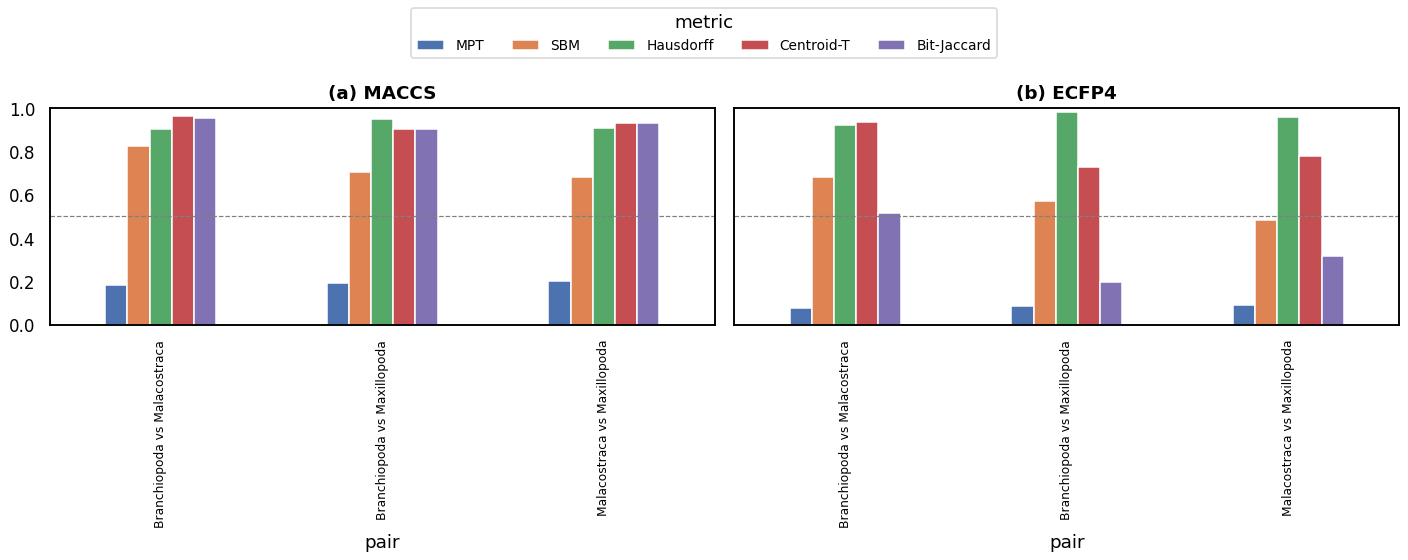

In [13]:
# 10B. The five set-vs-set metrics for every class pair (MACCS vs ECFP4)
metrics_to_plot = ["mean_pairwise_T", "symmetric_best_match_T",
                   "hausdorff_T_distance",
                   "centroid_continuous_T", "bit_union_jaccard"]
if len(sim_all) == 0:
    print("Only one class present - no between-class pairs to plot.")
else:
    _metric_short = {"mean_pairwise_T": "MPT", "symmetric_best_match_T": "SBM",
                     "hausdorff_T_distance": "Hausdorff",
                     "centroid_continuous_T": "Centroid-T",
                     "bit_union_jaccard": "Bit-Jaccard"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    for _k, (ax, fp) in enumerate(zip(axes, ["MACCS", "ECFP4"])):
        sub = sim_all[sim_all["fingerprint"] == fp].copy()
        sub["pair"] = sub["group_A"].astype(str) + " vs " + sub["group_B"].astype(str)
        (sub.set_index("pair")[metrics_to_plot]
            .rename(columns=_metric_short)
            .plot(kind="bar", ax=ax, legend=False))
        ax.set_title(f"({chr(97 + _k)}) {fp}")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="grey", lw=0.8, ls="--")
        ax.tick_params(axis="x", rotation=90, labelsize=8)
    _h, _l = axes[0].get_legend_handles_labels()
    fig.legend(_h, _l, loc="lower center", bbox_to_anchor=(0.5, 1.0),
               ncol=5, fontsize=9, title="metric", frameon=True)
    plt.tight_layout()
    plt.show()

> **Figure. Set-versus-set similarity-metric profile for every pair of classes.** Five set-level metrics computed between each pair of taxonomic classes (`tax_class`), shown separately per fingerprint — **(a)** MACCS (166-bit structural keys) and **(b)** ECFP4 (Morgan, radius 2, folded to 2048 bits). The x-axis lists the class pairs and bars are grouped by metric (legend): **MPT** = mean pairwise Tanimoto; **SBM** = symmetric best-match Tanimoto; **Hausdorff** = Hausdorff–Tanimoto distance (a *distance*: lower = more similar); **Centroid-T** = centroid continuous-Tanimoto; **Bit-Jaccard** = Jaccard overlap of the bit-union fingerprints. Values lie in 0–1; the dashed line at 0.5 is a visual reference. Higher bars mean greater between-class similarity for every metric except the Hausdorff distance.

In [14]:
# 10C. Render one example class group so we can eyeball the chemistry.
# (RDKit MolDraw2DSVG path; skipped cleanly if Draw is unavailable.)
from IPython.display import SVG

if not _DRAW_OK:
    print("Skipped: rdkit.Chem.Draw is not importable in this environment.")
    print(f"Reason : {_DRAW_ERROR}")
    print("Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1")
else:
    from rdkit.Chem.Draw import rdMolDraw2D

    group_label = list(group_maccs.keys())[0]                    # first class
    member_ids  = group_maccs[group_label]["compound_ids"]
    mols        = [data.loc[data.compound_id == cid, "mol"].iloc[0]
                   for cid in member_ids]

    mols_per_row = max(1, min(5, len(mols)))
    n_rows       = (len(mols) + mols_per_row - 1) // mols_per_row
    sub_w, sub_h = 220, 200

    drawer = rdMolDraw2D.MolDraw2DSVG(
        sub_w * mols_per_row, sub_h * max(1, n_rows), sub_w, sub_h)
    drawer.drawOptions().legendFontSize = 14
    drawer.DrawMolecules(mols, legends=member_ids)
    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()

    display(SVG(svg_text))

    # Persist this panel (vector SVG always, PNG if cairosvg is available)
    # into the shared high-resolution export folder FIG_DIR.
    _svg_path = FIG_DIR / "example_class_series.svg"
    _svg_path.write_text(svg_text, encoding="utf-8")
    _saved = [str(_svg_path)]
    try:
        import cairosvg
        _png_path = FIG_DIR / "example_class_series.png"
        cairosvg.svg2png(bytestring=svg_text.encode("utf-8"),
                         write_to=str(_png_path), dpi=FIG_DPI)
        _saved.append(str(_png_path))
    except Exception:
        pass
    print("Saved:", "   ".join(_saved))

Skipped: rdkit.Chem.Draw is not importable in this environment.
Reason : libXrender.so.1: cannot open shared object file: No such file or directory
Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1


> **Figure. Example structures from one taxonomic class.** Representative molecules taken from the first class in the dataset, drawn to give a visual sense of the chemistry; each structure is labelled with its compound identifier. Illustrative panel, not an exhaustive gallery.

### 10D &mdash; Set-vs-set metric profile between classes

The five set-vs-set metrics for every pair of classes, rendered as class&times;class
heat-maps (one figure per fingerprint), plus an intra-class homogeneity
reference panel.

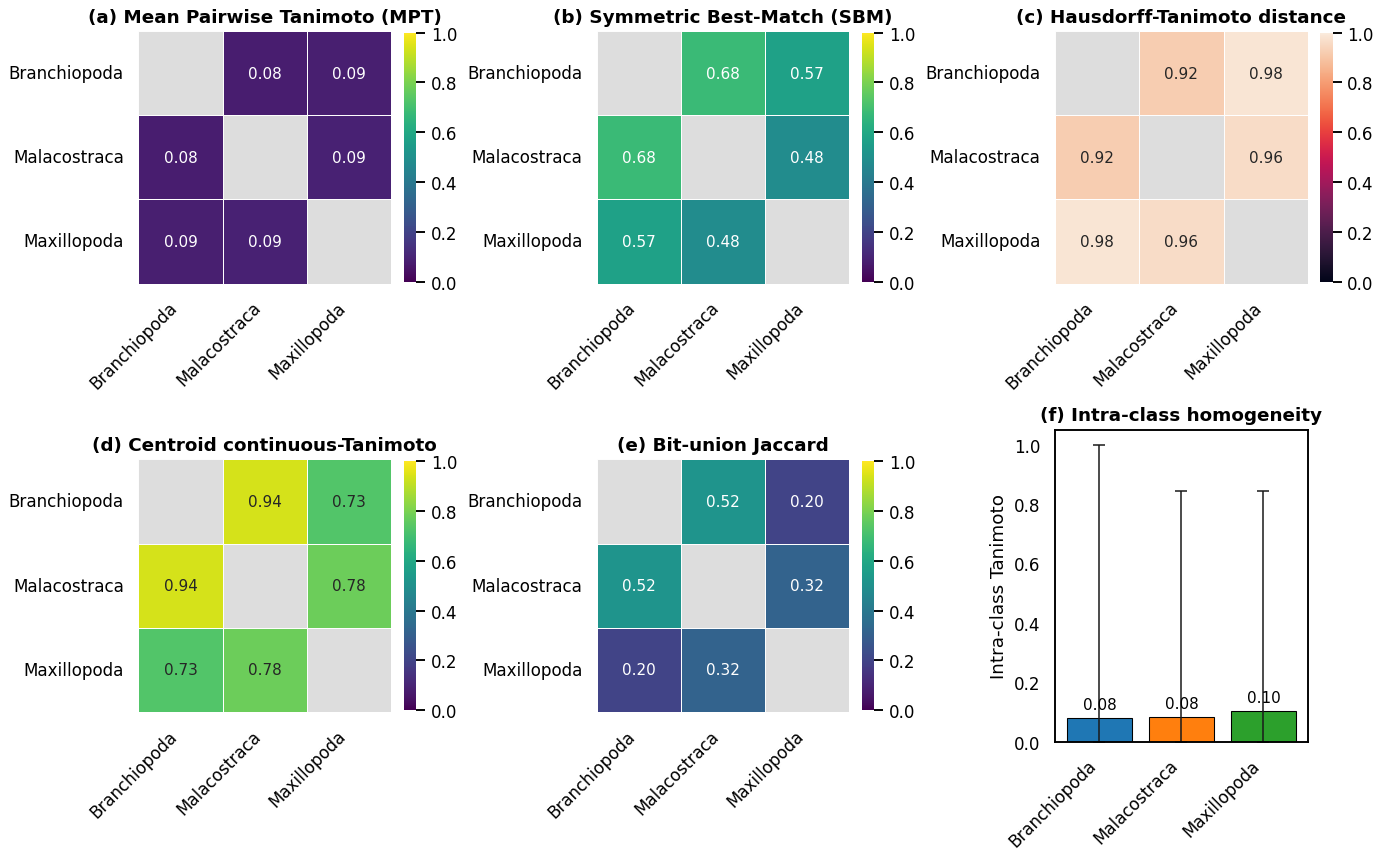

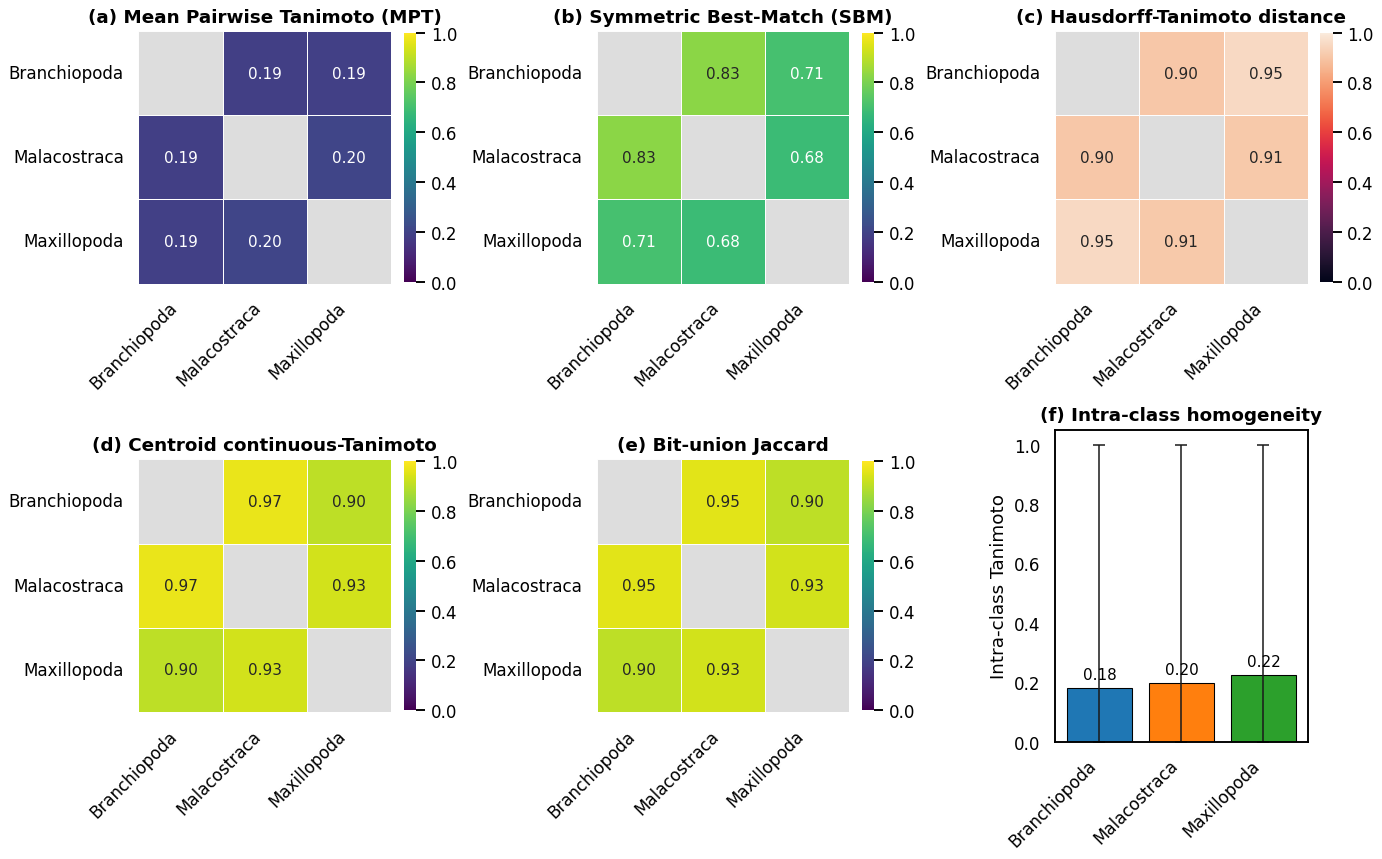

In [15]:
# === 10D. Dataset 1 set-vs-set metric profile: scaffold x scaffold heat-maps ===
# Renders the full `d1_all` similarity profile (5 metrics x 10 scaffold pairs)
# as one multi-panel figure per fingerprint, plus an intra-scaffold homogeneity
# reference panel built from `intra_d1`.  ECFP4 = main text; MACCS = supplement.
from pathlib import Path as _Path

# Publication figures are written next to the notebook (same folder used in 12.4).
_FIGDIR_10D = FIG_DIR  # unified export folder (created in the configuration cell)

# Grouping variable for this dataset = class.  Use the class names directly
# as the labels of the metric-profile heat-maps.
SCAFFOLD_ORDER = list(dict.fromkeys(data[GROUP_COL]))
SCAFFOLD_LABEL = {g: str(g) for g in SCAFFOLD_ORDER}

# (metric column, panel title, kind) — kind drives colormap & legend wording.
_D1_METRICS = [
    ("mean_pairwise_T",        "Mean Pairwise Tanimoto (MPT)",    "similarity"),
    ("symmetric_best_match_T", "Symmetric Best-Match (SBM)",      "similarity"),
    ("hausdorff_T_distance",   "Hausdorff-Tanimoto distance",     "distance"),
    ("centroid_continuous_T",  "Centroid continuous-Tanimoto",    "similarity"),
    ("bit_union_jaccard",      "Bit-union Jaccard",               "similarity"),
]

def _d1_metric_matrix(df_fp, metric, order):
    """Symmetric n x n matrix of one metric over all scaffold pairs (diag = NaN)."""
    idx = {k: i for i, k in enumerate(order)}
    M = np.full((len(order), len(order)), np.nan)
    for _, r in df_fp.iterrows():
        i, j = idx[r["group_A"]], idx[r["group_B"]]
        M[i, j] = M[j, i] = r[metric]
    return M

def plot_dataset1_metric_profile(d1_all, intra_d1, fp_label, save=True):
    """Multi-panel scaffold x scaffold heat-maps of the five set-vs-set metrics
    for Dataset 1, plus an intra-scaffold homogeneity panel.

    Parameters
    ----------
    d1_all : DataFrame from section 6 (five metric columns + group_A/group_B).
    intra_d1 : DataFrame from section 7 (intra-set mean/min/max Tanimoto / group).
    fp_label : "ECFP4" (main text) or "MACCS" (supplement).
    """
    df_fp  = d1_all[d1_all["fingerprint"] == fp_label]
    intra  = intra_d1[intra_d1["fingerprint"] == fp_label].set_index("group")
    labels = [SCAFFOLD_LABEL[k] for k in SCAFFOLD_ORDER]

    fig = plt.figure(figsize=(12.5, 7.8), constrained_layout=True)
    gs  = fig.add_gridspec(2, 3)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    for ax, (mkey, mtitle, kind), letter in zip(axes[:5], _D1_METRICS, "abcde"):
        M = _d1_metric_matrix(df_fp, mkey, SCAFFOLD_ORDER)
        sns.heatmap(M, ax=ax, cmap=("viridis" if kind == "similarity" else "rocket"),
                    vmin=0, vmax=1, square=True, annot=True, fmt=".2f",
                    annot_kws={"size": 10}, linewidths=0.6, linecolor="white",
                    cbar_kws={"shrink": 0.8}, xticklabels=labels, yticklabels=labels)
        for d in range(len(labels)):                       # mask degenerate diagonal
            ax.add_patch(plt.Rectangle((d, d), 1, 1, color="#dddddd",
                                       ec="white", lw=0.6, zorder=2))
        note = "" if kind == "similarity" else ""
        ax.set_title(f"({letter}) {mtitle}{note}", fontsize=12)
        ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
        for t in ax.get_xticklabels():
            t.set_ha("right")

    # (f) intra-scaffold homogeneity — the baseline that makes (a)-(e) interpretable
    axf  = axes[5]
    mean = np.array([intra.loc[k, "mean_T"] if k in intra.index else np.nan
                     for k in SCAFFOLD_ORDER], float)
    lo   = mean - np.array([intra.loc[k, "min_T"] if k in intra.index else np.nan
                            for k in SCAFFOLD_ORDER], float)
    hi   = np.array([intra.loc[k, "max_T"] if k in intra.index else np.nan
                     for k in SCAFFOLD_ORDER], float) - mean
    xs   = np.arange(len(SCAFFOLD_ORDER))
    axf.bar(xs, mean, color=sns.color_palette("tab10", len(SCAFFOLD_ORDER)),
            edgecolor="black", linewidth=0.7,
            yerr=[np.nan_to_num(lo), np.nan_to_num(hi)], capsize=4,
            error_kw={"elinewidth": 1.0})
    for x, m in zip(xs, mean):
        if not np.isnan(m):
            axf.text(x, m + 0.02, f"{m:.2f}", ha="center", va="bottom", fontsize=10)
    axf.set_xticks(xs); axf.set_xticklabels(labels, rotation=45, ha="right")
    axf.set_ylim(0, 1.05); axf.set_ylabel("Intra-class Tanimoto")
    axf.set_title("(f) Intra-class homogeneity",
                  fontsize=12)

    if save:
        stem = "fig_D1_metrics_ECFP4" if fp_label == "ECFP4" else "figS_D1_metrics_MACCS"
        fig.savefig(_FIGDIR_10D / f"{stem}.png", dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(_FIGDIR_10D / f"{stem}.pdf", bbox_inches="tight")
        fig._hr_exported = True  # curated names already written; skip auto-export
    plt.show()

# ECFP4 first (main text), then MACCS (supplementary).
plot_dataset1_metric_profile(d1_all, intra_d1, "ECFP4")
plot_dataset1_metric_profile(d1_all, intra_d1, "MACCS")

> **Figure. Class-by-class set-versus-set similarity profile.** For every pair of taxonomic classes, five set-level metrics are shown as colour-coded matrices: **(a)** mean pairwise Tanimoto (MPT), **(b)** symmetric best-match Tanimoto (SBM), **(c)** Hausdorff–Tanimoto distance (a *distance*: lower = closer), **(d)** centroid continuous-Tanimoto and **(e)** bit-union Jaccard. Rows and columns are the classes; the degenerate diagonal is masked in grey. Similarity panels use the viridis scale and the distance panel the rocket scale (both 0–1), with each cell annotated. Panel **(f)** is the intra-class homogeneity baseline (mean within-class Tanimoto; whiskers = min–max) that makes (a–e) interpretable. Produced for ECFP4 (main text) and MACCS (supplementary).

## 11. What to keep, what to throw away

* Keep the **5-metric profile** when discussing how similar two sets
  of compounds are.  Reporting a single number invites methodological
  disputes that the profile dissolves.
* Always pair set-vs-set scores with **intra-set diagnostics** -
  otherwise high scores can simply mean both sets are internally
  trivial.
* Always report **both** MACCS and ECFP4.  Agreement increases
  confidence; disagreement is itself useful information (it usually
  flags either coarse substructure overlap with very different
  detailed environments, or vice versa).
* The notebook is fully **self-contained, reproducible, and seeded**;
  re-running it on the same RDKit version must give bit-for-bit
  identical results.

# Part II — Extended data-science analysis

The remaining sections build a comprehensive **exploratory analysis**
on top of the foundations laid above.  Each new section is independent
of the others, so you can run or skip them in any order.

In [16]:
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Silence seaborn future-warnings about palette/hue ergonomics so the
# notebook output stays focused on the analysis.  These are cosmetic
# and do not affect the rendered figures.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
# UMAP also issues a benign UserWarning when the dataset is so small
# that the gradient descent converges in fewer than the default 200
# epochs.  This does not affect correctness on our test datasets.
warnings.filterwarnings("ignore", category=UserWarning, module="umap.*")
# sklearn's t-SNE warns when it converts uint8 fingerprints to bool
# for the Jaccard distance computation -- this is exactly what we
# want it to do.
try:
    from sklearn.exceptions import DataConversionWarning
    warnings.filterwarnings("ignore", category=DataConversionWarning)
except ImportError:
    pass

# Re-apply the publication style here: seaborn's set_theme would
# otherwise reset the text colours to grey.
apply_publication_style()

def fp_stack(df: pd.DataFrame, fp_col: str) -> np.ndarray:
    """Stack the binary fingerprints of a dataframe into a numpy matrix."""
    return np.vstack(df[fp_col].apply(fp_to_numpy).values) \
        if df[fp_col].dtype == object and len(df) > 0 else \
        np.zeros((0, 0), dtype=np.uint8)

# Pre-compute numpy versions of all fingerprints (we used to do this on the fly).
for _df in (data,):
    _df["maccs_np"] = _df["maccs_fp"].apply(fp_to_numpy)
    _df["ecfp4_np"] = _df["ecfp4_fp"].apply(fp_to_numpy)

def get_matrix(df, fp_kind):
    col = "maccs_np" if fp_kind == "MACCS" else "ecfp4_np"
    return np.vstack(df[col].values)

def reorder_by_clustering(S):
    """Return a row/column permutation that exposes the cluster
    structure of similarity matrix *S* (1 - S used as distance)."""
    D = 1.0 - S
    # Force the diagonal to exactly zero (within float tolerance)
    np.fill_diagonal(D, 0.0)
    # Symmetrise to remove any numerical drift
    D = (D + D.T) / 2
    cond = squareform(D, checks=False)
    Z = linkage(cond, method="average")
    return dendrogram(Z, no_plot=True)["leaves"], Z


### 12.1 &mdash; Structural EDA grouped by Murcko scaffold

A purely structural view: compounds are grouped by their Bemis&ndash;Murcko
scaffold.

*Disabled for this dataset:* this is a per-compound view (a pairwise heat-map and
clustering dendrogram over **every** compound) and does not scale to thousands of
compounds; the analysis here is grouped by class, so use the class-level
diagnostics in **12.2**. The `eda_dataset1` function is kept defined for reuse on
small, scaffold-grouped datasets.

In [17]:
def scaffold_label_series(df):
    """Readable scaffold labels (from the dominant compound-id prefix) so that
    axis ticks and legends never display the raw scaffold SMILES string."""
    _names = {"IND": "Indole", "QUI": "Quinoline", "BZI": "Benzimidazole",
              "CHR": "Chromone", "URA": "Uracil"}
    pref = df["compound_id"].astype(str).str.extract(r"^([A-Za-z]+)")[0]
    mapping, k = {}, 0
    for scaf in pd.unique(df["scaffold"]):
        m = (df["scaffold"] == scaf)
        p = pref[m].mode()
        p = (p.iloc[0] if len(p) else "")
        if p in _names:
            mapping[scaf] = _names[p]
        elif p and p.isalpha() and len(p) <= 5:
            mapping[scaf] = p.upper()
        else:
            k += 1
            mapping[scaf] = f"Sc{k}"
    return df["scaffold"].map(mapping)


def eda_dataset1(df, fp_kind="ECFP4"):
    """Multi-panel EDA for a dataset organised by Murcko scaffold.

    Skipped automatically when the dataset has more than MAX_VIZ_N compounds
    (the dense pairwise matrix, clustering and per-compound heat-map do not
    scale); the exact numeric metrics live in the d1_all / intra_d1 tables.
    """
    n = len(df)
    if viz_too_big(n, f"Dataset 1 EDA ({fp_kind})"):
        return

    X = get_matrix(df, fp_kind)
    S = pairwise_tanimoto_matrix(X, X)
    order, Z = reorder_by_clustering(S)
    df = df.copy()
    df["_scaf_disp"] = scaffold_label_series(df)

    _ACT = globals().get("ACTIVITY_COL", "pIC50")
    _ACTLAB = globals().get("ACTIVITY_LABEL", _ACT)
    has_pic50 = (_ACT in df.columns) and df[_ACT].notna().any()

    # Intra/inter-scaffold Tanimoto (vectorised over the upper triangle -- no
    # Python double loop, no n^2-length Python list).
    grp = df["scaffold"].values
    iu = np.triu_indices(len(grp), k=1)
    _vals = S[iu]
    _same = grp[iu[0]] == grp[iu[1]]
    intra = _vals[_same]
    inter = _vals[~_same]

    from string import ascii_lowercase
    _lab = iter(ascii_lowercase)
    nxt = lambda: f"({next(_lab)})"

    # ---- individual panel painters -------------------------------------
    def p_pic50_box(ax):
        sns.boxplot(data=df, x="_scaf_disp", y=_ACT, ax=ax,
                    hue="_scaf_disp", palette="tab10", legend=False)
        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.set_title(f"{nxt()} {_ACTLAB} by scaffold")
        ax.set_xlabel("")

    def p_counts(ax):
        df["_scaf_disp"].value_counts().plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{nxt()} Scaffold counts")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=10)

    def p_heatmap(ax):
        S_re = S[np.ix_(order, order)]
        ids = [df["compound_id"].iloc[i] for i in order]
        im = ax.imshow(S_re, vmin=0, vmax=1, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
        ax.set_xticklabels(ids, rotation=90, fontsize=8)
        ax.set_yticklabels(ids, fontsize=8)
        ax.set_title(f"{nxt()} Pairwise Tanimoto ({fp_kind}, clustered order)")
        plt.colorbar(im, ax=ax, fraction=0.04, label="Tanimoto")

    def p_violin(ax):
        sns.violinplot(data=[intra, inter], ax=ax, inner="box")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["intra-scaffold", "inter-scaffold"])
        ax.set_title(f"{nxt()} Within vs between scaffolds")
        ax.set_ylabel("Tanimoto")

    def p_dendro(ax):
        dendrogram(Z, labels=df["compound_id"].values, ax=ax, leaf_font_size=8,
                   leaf_rotation=45, color_threshold=0.55)
        ax.set_title(f"{nxt()} Hierarchical clustering ({fp_kind}, average linkage)")
        ax.set_ylabel("1 - Tanimoto")
        for _lbl in ax.get_xticklabels():
            _lbl.set_rotation(45); _lbl.set_ha("right"); _lbl.set_rotation_mode("anchor")

    # ---- assemble figure (layout depends on availability of pIC50) -----
    if has_pic50:
        fig = plt.figure(figsize=(12, 9), constrained_layout=True)
        gs = fig.add_gridspec(3, 3)
        p_pic50_box(fig.add_subplot(gs[0, 0]))
        p_counts(fig.add_subplot(gs[0, 1]))
        p_violin(fig.add_subplot(gs[0, 2]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_dendro(fig.add_subplot(gs[2, :]))
    else:
        fig = plt.figure(figsize=(12, 9.5), constrained_layout=True)
        gs = fig.add_gridspec(3, 2)
        p_counts(fig.add_subplot(gs[0, 0]))
        p_violin(fig.add_subplot(gs[0, 1]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_dendro(fig.add_subplot(gs[2, :]))

    plt.show()

    if len(intra):
        print(f"[{fp_kind}] mean intra-scaffold Tanimoto = {np.mean(intra):.3f}")
    if len(inter):
        print(f"[{fp_kind}] mean inter-scaffold Tanimoto = {np.mean(inter):.3f}")

# --- Section 12.1 figure DISABLED at user request -------------------------
# `eda_dataset1` (per-compound scaffold heat-map + dendrogram) is NOT rendered:
# it does not scale to thousands of compounds, and this dataset is grouped by
# class (tax_class), so the class-level diagnostics in 12.2 are the relevant
# view. The function above is kept defined so analyze_dataset(group_col=
# "scaffold") still works on small, scaffold-grouped datasets.
print("Section 12.1 (per-compound scaffold EDA) is disabled for this dataset.")


Section 12.1 (per-compound scaffold EDA) is disabled for this dataset.


### 12.2 &mdash; EDA grouped by class (`tax_class`)

The class-level view: compounds are grouped by `tax_class`, with a **pLC50
distribution**, a **pLC50-by-class violin**, a **shared-vs-unique** structure
breakdown across classes, and a **within- vs between-class Tanimoto violin**.

The per-compound *pairwise-Tanimoto heat-map* and *clustering dendrogram* panels
have been removed. The within/between-class violin is the only panel that needs
all pairwise similarities, so for large datasets it is computed on a
representative random subsample (the other panels always use every compound).

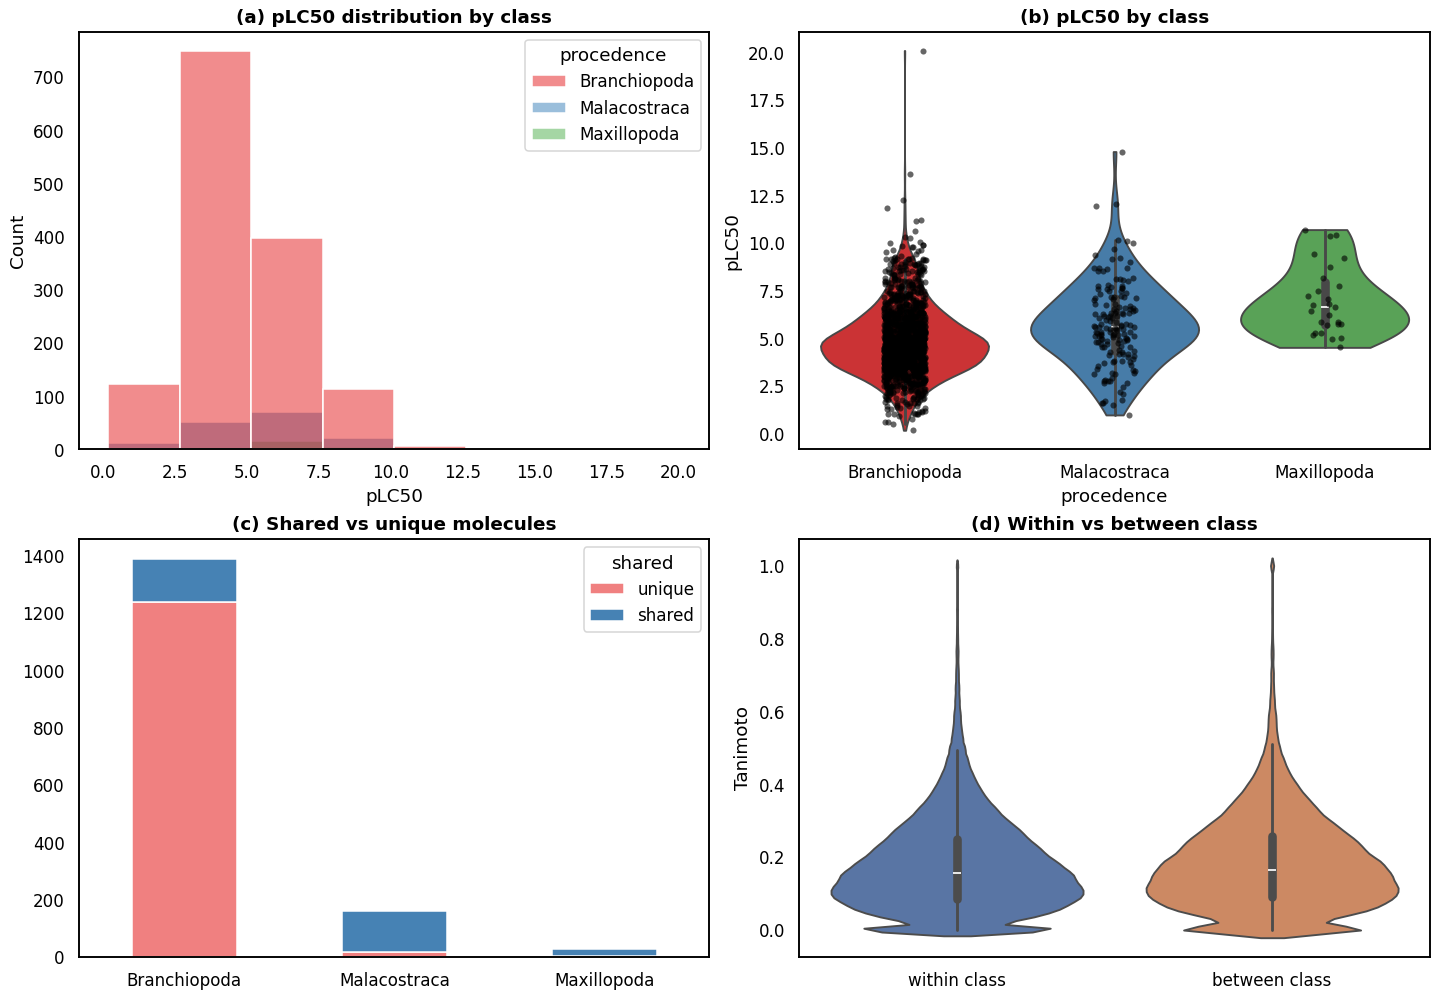

[MACCS] mean within-class Tanimoto = 0.181
[MACCS] mean between-class Tanimoto = 0.186


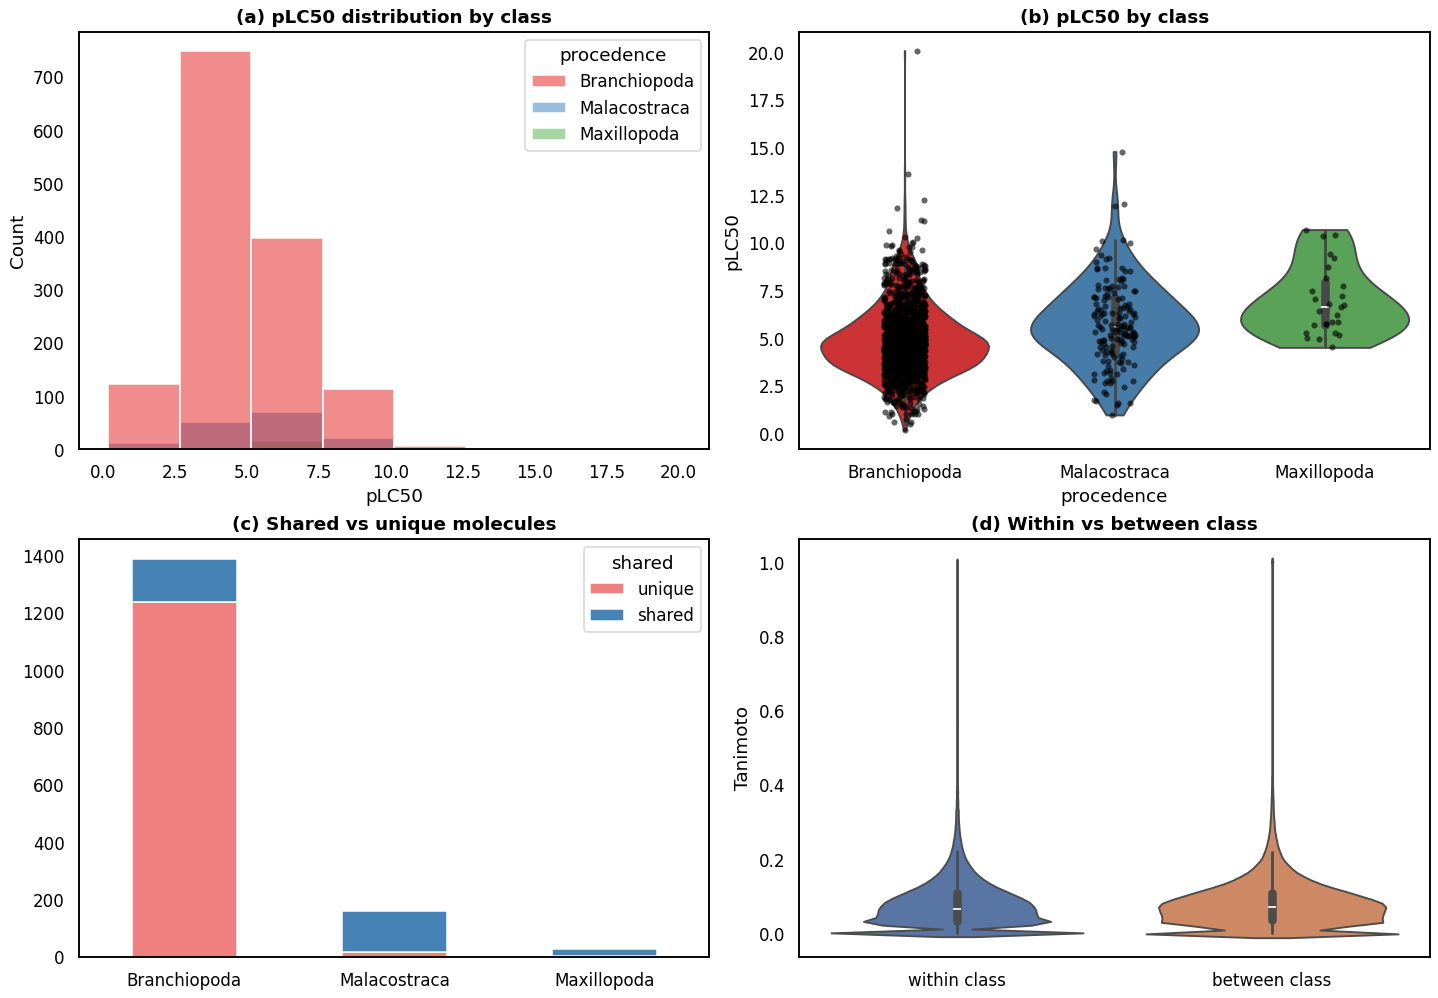

[ECFP4] mean within-class Tanimoto = 0.079
[ECFP4] mean between-class Tanimoto = 0.080


In [18]:
def eda_procedence_dataset(df, fp_kind="ECFP4", title=""):
    """Class-level EDA (grouped by ``procedence``).

    Trimmed version requested by the user:
      * the per-compound *Pairwise Tanimoto* heat-map and the *Hierarchical
        clustering* dendrogram panels have been REMOVED;
      * the pLC50-by-class panel is drawn as a VIOLIN (was a box plot).

    The within/between-class Tanimoto violin is the only O(n^2) panel left, so
    for large datasets it is computed on a representative random SUBSAMPLE
    (seeded with RANDOM_SEED) to stay memory-safe; the lightweight panels
    always use the full dataset. The figure therefore always renders.
    """
    _ACT = globals().get("ACTIVITY_COL", "pIC50")
    _ACTLAB = globals().get("ACTIVITY_LABEL", _ACT)
    has_pic50 = (_ACT in df.columns) and df[_ACT].notna().any()

    # Shared vs unique canonical SMILES across classes (full data).
    counts_by_smiles = (df.groupby("canonical_smiles")["procedence"]
                          .nunique().reset_index(name="n_groups"))
    shared_smiles = set(counts_by_smiles.loc[counts_by_smiles["n_groups"] > 1,
                                             "canonical_smiles"])
    df = df.assign(shared=df["canonical_smiles"].isin(shared_smiles))

    # Within/between-class Tanimoto distribution (the only heavy panel).
    # Subsample for large n so it never materialises a huge pairwise matrix.
    n = len(df)
    if n > MAX_VIZ_N:
        _rng = np.random.default_rng(RANDOM_SEED)
        _sidx = np.sort(_rng.choice(n, size=MAX_VIZ_N, replace=False))
        df_s = df.iloc[_sidx]
        _vnote = f" (subsample n={MAX_VIZ_N})"
    else:
        df_s = df
        _vnote = ""
    Xs = get_matrix(df_s, fp_kind)
    S = pairwise_tanimoto_matrix(Xs, Xs)
    grp = df_s["procedence"].values
    iu = np.triu_indices(len(grp), k=1)
    _vals = S[iu]
    _same = grp[iu[0]] == grp[iu[1]]
    intra = _vals[_same]
    inter = _vals[~_same]

    from string import ascii_lowercase
    _lab = iter(ascii_lowercase)
    nxt = lambda: f"({next(_lab)})"

    def p_pic50_hist(ax):
        sns.histplot(data=df, x=_ACT, hue="procedence", multiple="layer",
                     bins=8, ax=ax, palette="Set1")
        ax.set_title(f"{nxt()} {_ACTLAB} distribution by class")

    def p_pic50_violin(ax):
        # pLC50 by class as a VIOLIN (replaces the former box plot).
        sns.violinplot(data=df, x="procedence", y=_ACT, ax=ax,
                       hue="procedence", palette="Set1", legend=False,
                       inner="box", cut=0)
        if len(df) <= MAX_VIZ_N:                       # overlay points only when readable
            sns.stripplot(data=df, x="procedence", y=_ACT, ax=ax, color="black",
                          size=4, alpha=0.6)
        ax.set_title(f"{nxt()} {_ACTLAB} by class")

    def p_shared_unique(ax):
        summary = (df.groupby(["procedence", "shared"]).size()
                   .unstack(fill_value=0)
                   .rename(columns={False: "unique", True: "shared"}))
        for col in ("unique", "shared"):
            if col not in summary.columns:
                summary[col] = 0
        summary = summary[["unique", "shared"]]
        summary.plot(kind="bar", stacked=True, ax=ax,
                     color=["lightcoral", "steelblue"])
        ax.set_title(f"{nxt()} Shared vs unique molecules")
        ax.tick_params(axis="x", rotation=0)
        ax.set_xlabel("")

    def p_violin(ax):
        sns.violinplot(data=[intra, inter], ax=ax, inner="box")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["within class", "between class"])
        ax.set_ylabel("Tanimoto")
        ax.set_title(f"{nxt()} Within vs between class{_vnote}")

    # Layout: with pLC50 -> 2x2 (hist, pLC50 violin, shared/unique, T-violin);
    # without -> 1x2 (shared/unique, T-violin).
    if has_pic50:
        fig = plt.figure(figsize=(13, 9), constrained_layout=True)
        gs = fig.add_gridspec(2, 2)
        p_pic50_hist(fig.add_subplot(gs[0, 0]))
        p_pic50_violin(fig.add_subplot(gs[0, 1]))
        p_shared_unique(fig.add_subplot(gs[1, 0]))
        p_violin(fig.add_subplot(gs[1, 1]))
    else:
        fig = plt.figure(figsize=(13, 5), constrained_layout=True)
        gs = fig.add_gridspec(1, 2)
        p_shared_unique(fig.add_subplot(gs[0, 0]))
        p_violin(fig.add_subplot(gs[0, 1]))

    plt.show()
    if len(intra):
        print(f"[{fp_kind}] mean within-class Tanimoto = {np.mean(intra):.3f}{_vnote}")
    if len(inter):
        print(f"[{fp_kind}] mean between-class Tanimoto = {np.mean(inter):.3f}{_vnote}")

eda_procedence_dataset(data, "MACCS", title=DATASET_TITLE)
eda_procedence_dataset(data, "ECFP4", title=DATASET_TITLE)


> **Figure. Exploratory analysis grouped by taxonomic class.** Panels: **(a)** distribution of pLC50 (= −log10 of LC50 in mol/L) by class; **(b)** pLC50 by class as a violin (individual points overlaid when the dataset is small enough); **(c)** number of molecules unique to a class versus shared across classes; **(d)** distribution of pairwise Tanimoto similarities within the same class versus between classes (for large datasets this panel is computed on a seeded random subsample, noted in the panel title). Produced for both fingerprints (MACCS and ECFP4).

## 13. Choosing a dimensionality-reduction method for chemical space

We need to project the 167- or 2048-bit fingerprints into 2-D so the
**three datasets can be visualised together** on one plane.  Three
methods are commonly used in cheminformatics:

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **PCA** | Linear projection onto axes of maximum variance | Deterministic, fast, interpretable; explained-variance ratio is meaningful | Assumes Euclidean / Gaussian structure; sparse binary fingerprints violate both assumptions; usually <40% variance captured by 2 PCs on 2048-bit ECFP4 |
| **t-SNE** | Stochastic neighbour embedding | Strong local-structure preservation | Very sensitive to perplexity, unstable when *n* is small (perplexity must be < *n*/3), global distances are not meaningful |
| **UMAP** | Manifold approximation + topological optimisation | Preserves both local and global structure better than t-SNE; accepts **Jaccard / Tanimoto metric natively**; works on small *n*; deterministic given a seed | Stochastic in the absence of a seed; result depends on `n_neighbors` and `min_dist` |

### Decision: UMAP with `metric='jaccard'`

The deciding argument is **the metric**.  Our fingerprints are binary
vectors; the natural notion of similarity between binary vectors is
Jaccard / Tanimoto, *not* Euclidean.  UMAP is the only one of the
three that operates **directly in the original Tanimoto-distance
space** without first projecting into a Euclidean approximation,
which is critical when working with extended-connectivity
fingerprints whose bits are not orthogonal.

For comparison, the next code cell runs all three methods on the
combined dataset so the user can see the difference for themselves.

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Build a combined dataframe so we can plot all three datasets together.
# Single dataset: colour / label the nodes by class.
all_df = data.assign(source=data[GROUP_COL].astype(str),
                     group_label=data[GROUP_COL].astype(str)).reset_index(drop=True)

X_all_maccs = get_matrix(all_df, "MACCS")
X_all_ecfp  = get_matrix(all_df, "ECFP4")
print("Combined dataset shape:", all_df.shape)

# Reasonable UMAP hyperparameters for small datasets.
N_NEIGHBORS = max(2, min(15, len(all_df) // 4))
MIN_DIST    = 0.25

def run_umap(X, metric="jaccard", seed=RANDOM_SEED):
    return umap.UMAP(n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST,
                     metric=metric, random_state=seed,
                     n_components=2).fit_transform(X)

def run_pca(X, seed=RANDOM_SEED):
    pca = PCA(n_components=2, random_state=seed)
    Z = pca.fit_transform(X.astype(np.float32))
    return Z, pca.explained_variance_ratio_

def run_tsne(X, metric="jaccard", seed=RANDOM_SEED):
    perp = max(5, min(30, (X.shape[0] - 1) // 3))
    return TSNE(n_components=2, perplexity=perp, random_state=seed,
                metric=metric, init="random",
                learning_rate="auto").fit_transform(X.astype(np.float32))

# The 2-D embeddings are per-compound figures; t-SNE with a non-Euclidean
# metric in particular builds an O(n^2) distance matrix. Skip them for large N.
_EMBED_OK = len(all_df) <= MAX_VIZ_N
if _EMBED_OK:
    Z_umap_ecfp  = run_umap(X_all_ecfp,  "jaccard")
    Z_umap_maccs = run_umap(X_all_maccs, "jaccard")
    Z_pca_ecfp, evr_ecfp = run_pca(X_all_ecfp)
    Z_tsne_ecfp = run_tsne(X_all_ecfp, "jaccard")
    print(f"PCA on ECFP4 explained variance (2 PCs): "
          f"{evr_ecfp[0]:.2%}, {evr_ecfp[1]:.2%}, total {evr_ecfp.sum():.2%}")
else:
    Z_umap_ecfp = Z_umap_maccs = Z_pca_ecfp = Z_tsne_ecfp = None
    evr_ecfp = None
    viz_too_big(len(all_df), "PCA / t-SNE / UMAP embeddings")


Combined dataset shape: (1574, 15)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PCA on ECFP4 explained variance (2 PCs): 5.28%, 3.98%, total 9.27%


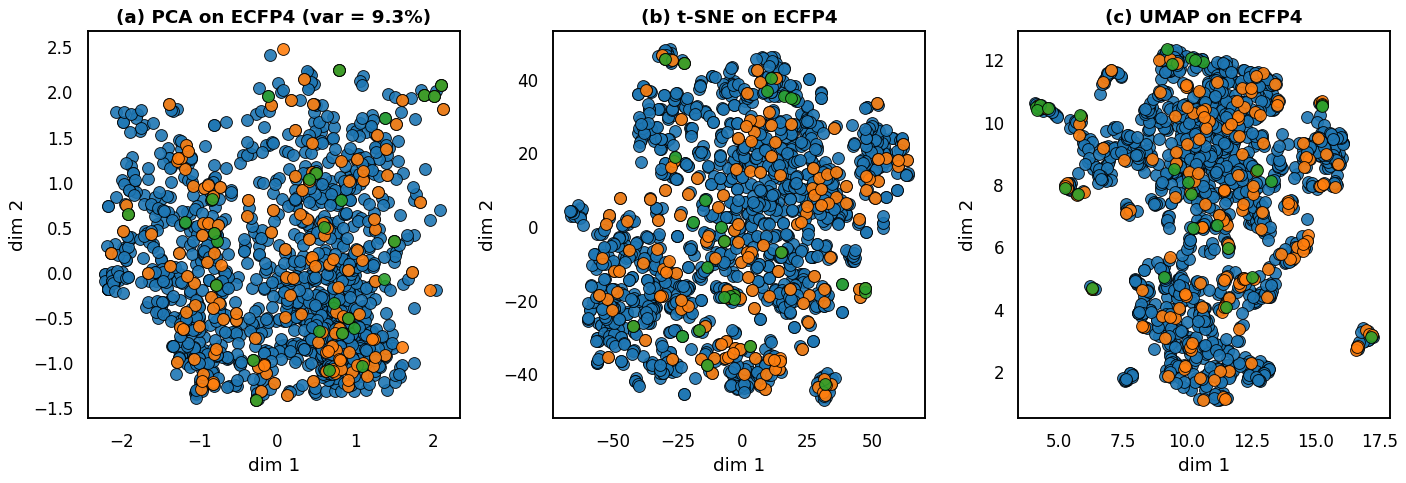

In [20]:
# Visual comparison: same data, three projection methods (coloured by class).
if not _EMBED_OK or Z_pca_ecfp is None:
    print(f"[skip] projection-method comparison: embeddings not computed "
          f"(N={len(all_df)} > MAX_VIZ_N={MAX_VIZ_N}).")
else:
    _levels = list(dict.fromkeys(all_df["source"]))
    _pal = sns.color_palette("tab10", n_colors=max(3, len(_levels)))
    src_colors = {lev: _pal[i] for i, lev in enumerate(_levels)}

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
    for ax, Z, title in zip(
        axes,
        [Z_pca_ecfp, Z_tsne_ecfp, Z_umap_ecfp],
        [f"(a) PCA on ECFP4 (var = {evr_ecfp.sum():.1%})",
         "(b) t-SNE on ECFP4",
         f"(c) UMAP on ECFP4"],
    ):
        for src, c in src_colors.items():
            m = (all_df["source"] == src).values
            ax.scatter(Z[m, 0], Z[m, 1], s=60, c=[c], edgecolor="black",
                       linewidth=0.6, label=src, alpha=0.9)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
        #ax.legend(fontsize=10, frameon=True, title="class")
    plt.tight_layout()
    plt.show()


> **Figure. Two-dimensional projections of the chemical space, coloured by class.** All compounds embedded from their ECFP4 fingerprints with three methods: **(a)** PCA (linear; variance captured by the two components is given), **(b)** t-SNE (Jaccard distance, automatic perplexity) and **(c)** UMAP (Jaccard distance; number of neighbours given). Each point is one compound, coloured by taxonomic class (legend). The three views are shown together because each preserves a different aspect of the high-dimensional structure (global variance vs local neighbourhoods).

## 14. Chemical-space network across all datasets

For the final visualisation we combine:

1.  **One UMAP embedding** of all compounds from the dataset, so that
    every node has a fixed 2-D position that is comparable across
    panels.
2.  **One panel per fingerprint** (MACCS, ECFP4).  Each panel uses the
    *same* UMAP layout but draws edges based on its own pairwise
    Tanimoto matrix.  This makes the visual comparison between
    fingerprints honest — only the connectivity differs between
    panels, not the node positions.
3.  **Edges are drawn for compound pairs with Tanimoto >= threshold**
    (default 0.4 for ECFP4, 0.65 for MACCS — different thresholds
    because the two fingerprints have very different value ranges).
4.  **Edge colour encodes similarity** on a white -> black gradient
    (`Greys` colormap): pairs with low Tanimoto fade into the
    background, pairs with high Tanimoto are drawn in solid black.
5.  **Edge width** is also scaled to similarity for additional
    emphasis.

### Why a threshold?

Without one, every pair contributes an edge — that's
`n*(n-1)/2 = 49*48/2 = 1176` edges in our case, which produces an
illegible black square.  Setting a sensible threshold is the standard
practice for compound-similarity networks (see e.g. Maggiora 2014;
Yongye et al. 2012).  The thresholds chosen here are *defaults* and
can be tuned via the `tanimoto_thresholds` argument.

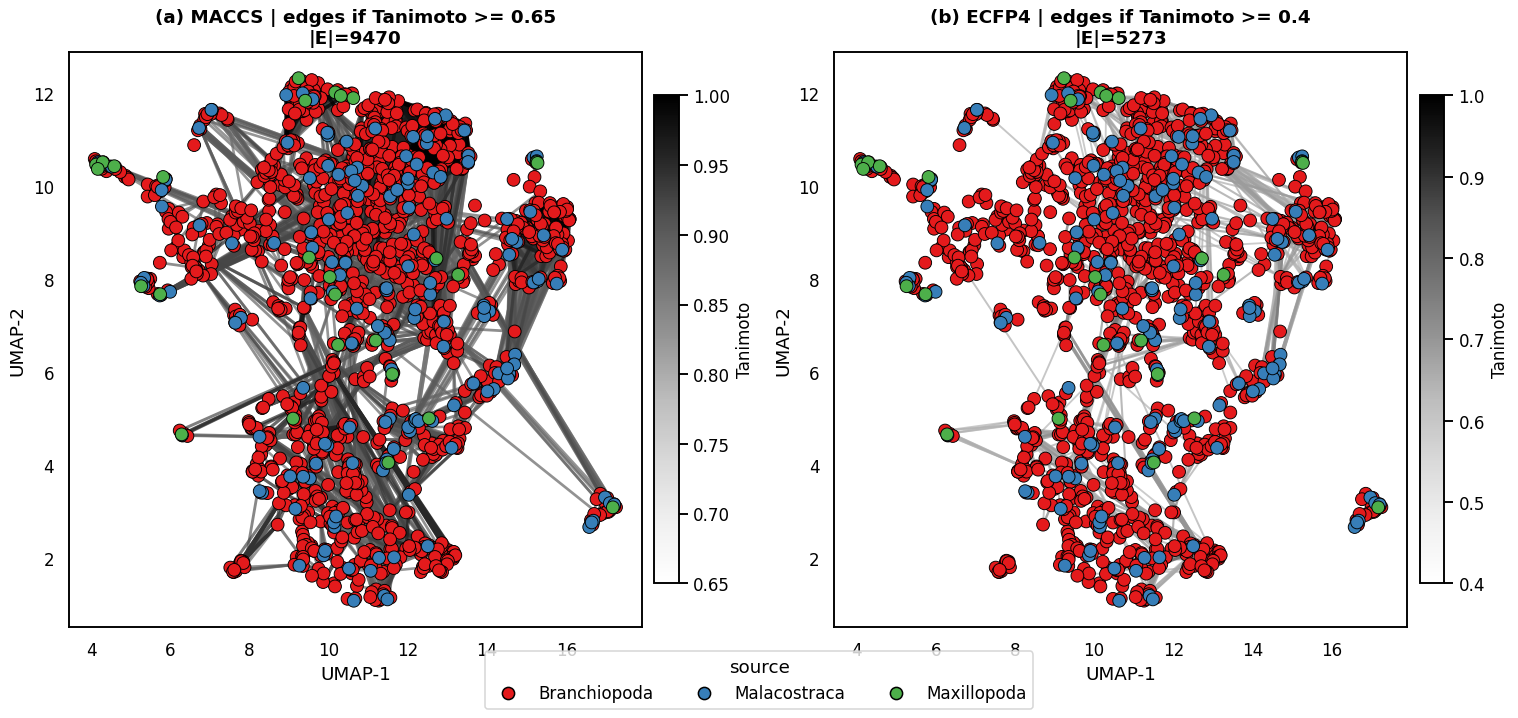

In [21]:
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib import colormaps

def chemical_space_network(
    df,
    embedding,
    tanimoto_thresholds=None,
    fingerprints=("MACCS", "ECFP4"),
    node_color_by="source",
    title="Chemical-space network",
    figsize=None,
):
    """Multi-panel chemical-space network.

    Skipped automatically when there is no embedding or the dataset has more
    than MAX_VIZ_N compounds (the all-pairs edge set is O(n^2))."""
    n = len(df)
    if embedding is None or viz_too_big(n, "chemical-space network"):
        return None

    if tanimoto_thresholds is None:
        tanimoto_thresholds = {"MACCS": 0.65, "ECFP4": 0.40}

    if figsize is None:
        figsize = (7 * len(fingerprints), 6.5)

    fig, axes = plt.subplots(1, len(fingerprints), figsize=figsize,
                             squeeze=False)
    axes = axes[0]

    # Build node colours
    levels = list(dict.fromkeys(df[node_color_by]))   # order-preserving unique
    palette = sns.color_palette("Set1", n_colors=len(levels))
    color_map = dict(zip(levels, palette))
    node_colors = df[node_color_by].map(color_map).values

    grey_cmap = colormaps["Greys"]  # white = 0.0, black = 1.0

    for pi, (ax, fp_kind) in enumerate(zip(axes, fingerprints)):
        X = get_matrix(df, fp_kind)
        S = pairwise_tanimoto_matrix(X, X)
        thr = tanimoto_thresholds[fp_kind]

        # --- Collect edges (vectorised over the upper triangle) ---
        iu = np.triu_indices(n, k=1)
        w = S[iu]
        keep = w >= thr
        ii = iu[0][keep]; jj = iu[1][keep]; ww = w[keep]
        G = nx.Graph()
        G.add_nodes_from(range(n))
        G.add_weighted_edges_from(zip(ii.tolist(), jj.tolist(), ww.tolist()))

        # --- Draw edges first (under the nodes), lightest -> darkest ---
        order = np.argsort(ww)
        for k in order:
            i, j, s = int(ii[k]), int(jj[k]), float(ww[k])
            ax.plot([embedding[i, 0], embedding[j, 0]],
                    [embedding[i, 1], embedding[j, 1]],
                    color=grey_cmap(s), lw=0.4 + 2.0 * s,
                    alpha=0.7, zorder=1)

        # --- Draw nodes ---
        ax.scatter(embedding[:, 0], embedding[:, 1],
                   c=node_colors, s=70, edgecolor="black",
                   linewidth=0.6, zorder=3)

        # --- Per-compound labels removed at user request (kept clean) ---

        ax.set_title(f"({chr(97+pi)}) {fp_kind} | edges if Tanimoto >= {thr}\n"
                     f"|E|={G.number_of_edges()}", fontsize=12)
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
        ax.grid(False)

        sm = plt.cm.ScalarMappable(cmap=grey_cmap,
                                   norm=plt.Normalize(vmin=thr, vmax=1.0))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
        cbar.set_label("Tanimoto", fontsize=11)

    handles = [Line2D([0], [0], marker="o", linestyle="",
                      markerfacecolor=color_map[g], markeredgecolor="black",
                      markersize=8, label=str(g)) for g in levels]
    fig.legend(handles=handles, title=node_color_by,
               loc="lower center", ncol=min(len(levels), 6),
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    plt.tight_layout()
    plt.show()
    return G

_ = chemical_space_network(
    all_df, Z_umap_ecfp,
    title="Chemical-space network (UMAP from ECFP4, edges = pairwise Tanimoto)",
    node_color_by="source",
)


> **Figure. Chemical-space similarity network, coloured by class.** Nodes are compounds placed at their shared UMAP coordinates (ECFP4, Jaccard); two nodes are joined when their pairwise Tanimoto similarity reaches the panel threshold — **(a)** MACCS (≥ 0.65) and **(b)** ECFP4 (≥ 0.40). Edge shade and width encode the Tanimoto value (darker/thicker = more similar; see colour bar) and *|E|* is the number of edges drawn. Node colour denotes the taxonomic class (legend).

## 15. Reusable pipeline for any dataset

The function below packages **all** of the extended analysis behind a
single, validated entry point that accepts any user-supplied
dataframe with the minimum schema:

* required columns: `compound_id`, `smiles`
* optional columns: `pIC50`, and any *group* column the user wants to
  inspect (e.g. `scaffold`, `procedence`, `assay`, `series`, ...).

`analyze_dataset(df, group_col=...)` runs the full pipeline and
returns a dictionary with all the computed artefacts so the user
can integrate it into a larger workflow.

In [22]:
def analyze_dataset(
    df,
    group_col=None,
    pic50_col="pLC50",
    fingerprints=("MACCS", "ECFP4"),
    tanimoto_thresholds=None,
    umap_kwargs=None,
    eda=True,
    network=True,
    title="user-supplied dataset",
):
    """Run the full extended analysis on an arbitrary dataframe.

    Memory-aware: the dense per-fingerprint Tanimoto matrices, the EDA figures,
    the 2-D embedding and the network are only built when the dataset has at
    most MAX_VIZ_N compounds. Above that they are skipped (the annotated frame
    and fingerprint matrices are still returned, and the exact set-vs-set
    metrics remain available through the section-6/7 tables).

    Returns
    -------
    dict with keys: "annotated", "matrices", "tanimoto", "embedding", "graph".
    """
    for col in ("compound_id", "smiles"):
        if col not in df.columns:
            raise ValueError(f"Required column missing: {col!r}")
    df = df.copy()

    # --- Annotate -----------------------------------------------------
    ann = annotate(df)
    ann["maccs_np"] = ann["maccs_fp"].apply(fp_to_numpy)
    ann["ecfp4_np"] = ann["ecfp4_fp"].apply(fp_to_numpy)

    if group_col is None:
        group_col = "scaffold"
    elif group_col not in ann.columns:
        raise ValueError(
            f"group_col {group_col!r} not in dataframe and not auto-derivable")

    # Colour the network by a readable scaffold label (never the raw SMILES).
    net_color_col = group_col
    if group_col == "scaffold":
        ann["scaffold_label"] = scaffold_label_series(ann)
        net_color_col = "scaffold_label"

    n = len(ann)
    small_enough = n <= MAX_VIZ_N

    # --- Fingerprint matrices (cheap) and Tanimoto matrices (only if small) --
    matrices, tanimoto = {}, {}
    for fp in fingerprints:
        matrices[fp] = get_matrix(ann, fp)
    if small_enough:
        for fp in fingerprints:
            tanimoto[fp] = pairwise_tanimoto_matrix(matrices[fp], matrices[fp])
    else:
        for fp in fingerprints:
            tanimoto[fp] = None
        print(f"[analyze_dataset] N={n} > MAX_VIZ_N={MAX_VIZ_N}: dense Tanimoto "
              f"matrices, the 2-D embedding and the network are skipped to protect "
              f"memory (the trimmed class-level EDA in 12.2 still renders). "
              f"Returning annotated frame + fingerprint matrices.")

    # --- EDA (the painters self-skip for large N too) -----------------
    if eda:
        if group_col == "scaffold":
            for fp in fingerprints:
                eda_dataset1(ann, fp_kind=fp)
        else:
            for fp in fingerprints:
                eda_procedence_dataset(ann.rename(columns={group_col: "procedence"}),
                                       fp_kind=fp, title=title)

    # --- UMAP embedding + network (only when small) -------------------
    Z = None
    G = None
    if small_enough:
        kw = dict(n_neighbors=max(2, min(15, len(ann) // 4)),
                  min_dist=0.25, metric="jaccard",
                  random_state=RANDOM_SEED, n_components=2)
        if umap_kwargs:
            kw.update(umap_kwargs)
        primary_fp = fingerprints[0]
        Z = umap.UMAP(**kw).fit_transform(matrices[primary_fp])
        if network:
            G = chemical_space_network(
                ann, Z,
                tanimoto_thresholds=tanimoto_thresholds,
                fingerprints=fingerprints,
                node_color_by=net_color_col,
                title=f"{title} | chemical-space network ({primary_fp} UMAP layout)",
            )

    return {
        "annotated": ann,
        "matrices":  matrices,
        "tanimoto":  tanimoto,
        "embedding": Z,
        "graph":     G,
    }


### Demonstration: run `analyze_dataset` on each dataset

Each call reruns the entire pipeline (annotation, EDA, embedding, network) on a
single dataset, confirming that the wrapper reproduces the section-by-section
results above. These cells are the most computationally intensive in the notebook.


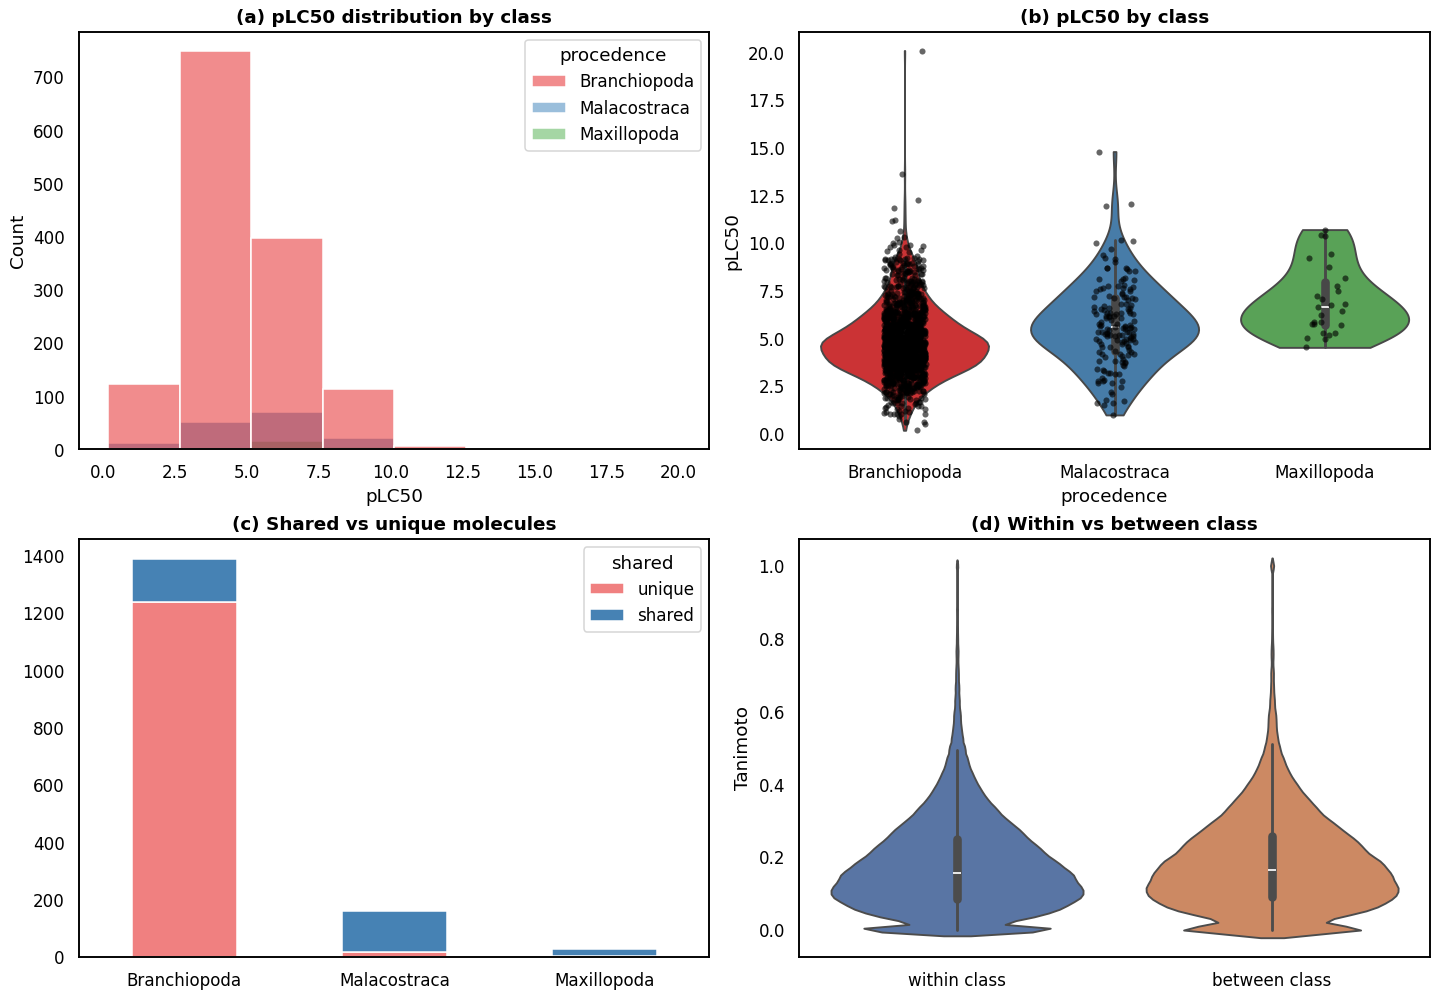

[MACCS] mean within-class Tanimoto = 0.181
[MACCS] mean between-class Tanimoto = 0.186


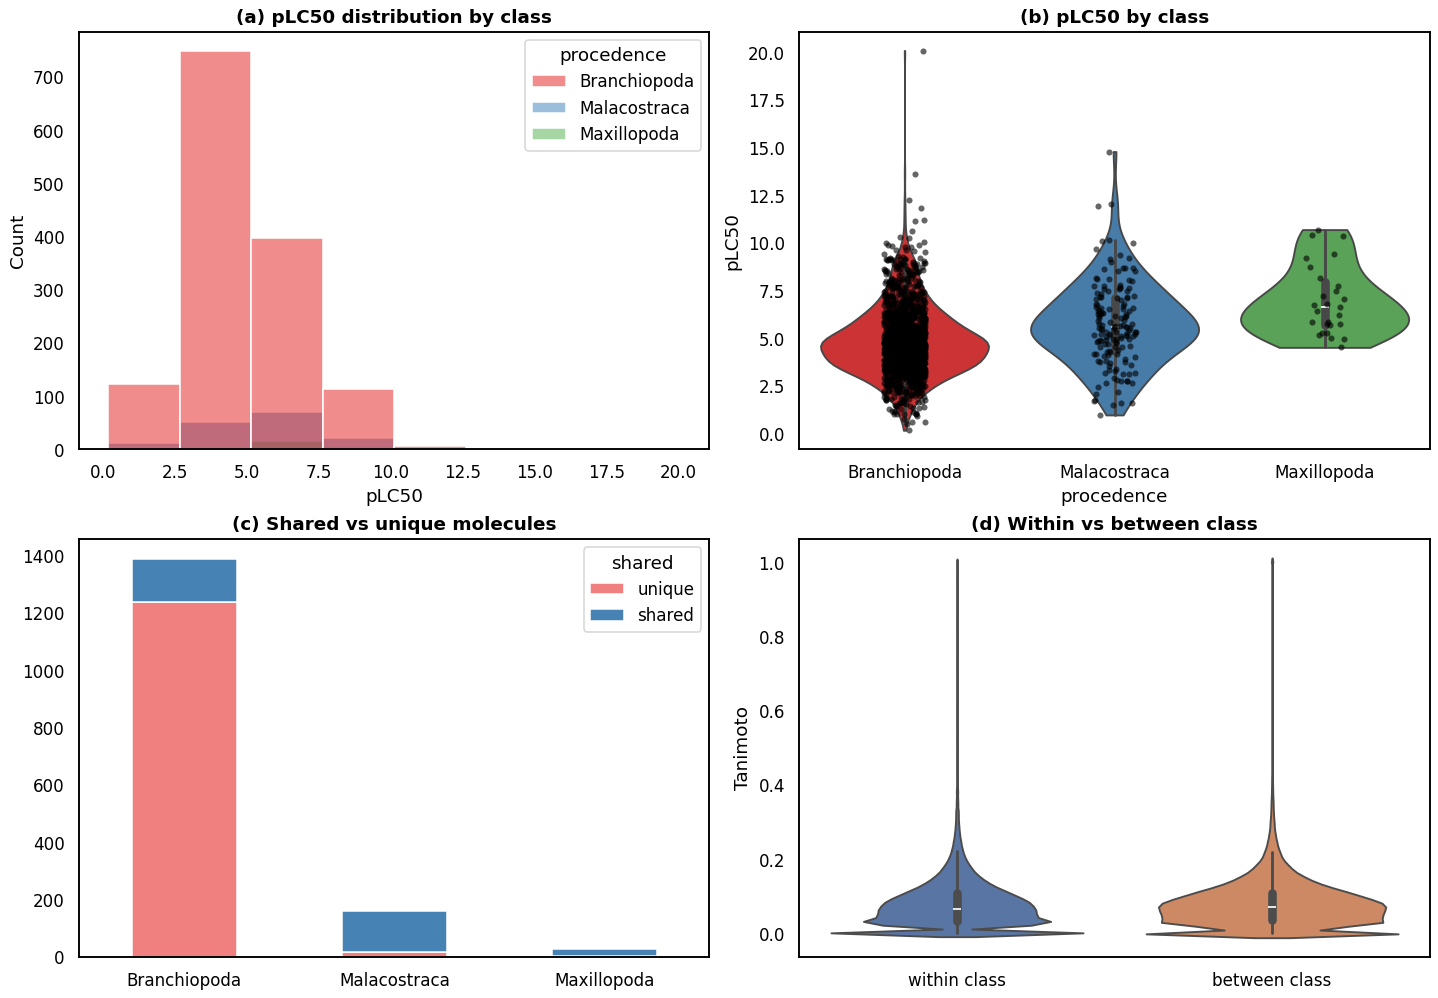

[ECFP4] mean within-class Tanimoto = 0.079
[ECFP4] mean between-class Tanimoto = 0.080


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


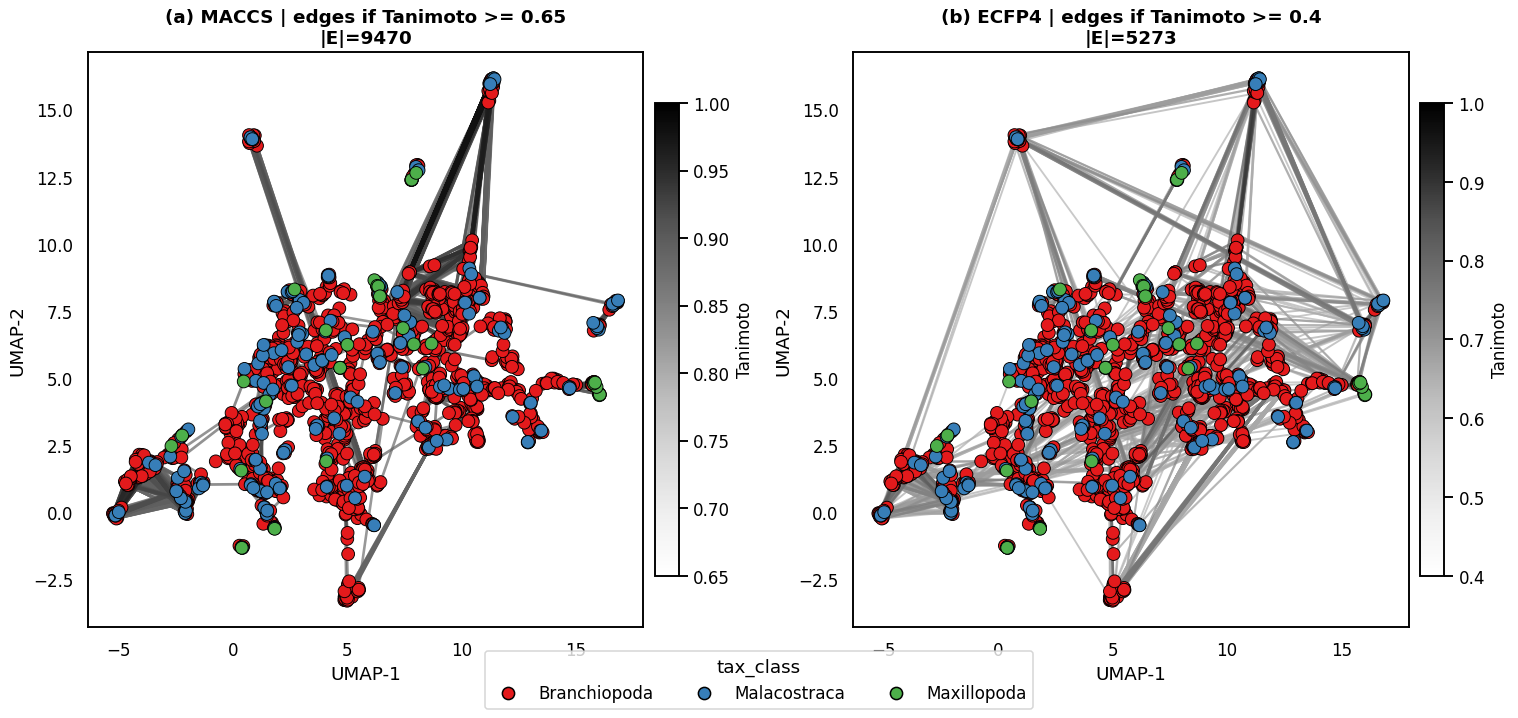

In [23]:
# Full end-to-end analysis of YOUR dataset, grouped by class, using pLC50.
result = analyze_dataset(
    df[["compound_id", "smiles", "tax_class", "pLC50"]],
    group_col="tax_class",
    pic50_col="pLC50",
    title=DATASET_TITLE,
    network=True,
)

> **Figure. End-to-end analysis through the generic `analyze_dataset` pipeline (grouped by class).** Reproduces the class-level EDA and the chemical-space network for both fingerprints (MACCS and ECFP4); panel definitions are the same as in the corresponding EDA and network figures above.

In [24]:
# (The original notebook ran extra demos on synthetic Datasets 2 & 3.
#  With a single real dataset, the analysis above already covers it.)
print("Datasets 2 & 3 were synthetic examples; not applicable to a single CSV.")

Datasets 2 & 3 were synthetic examples; not applicable to a single CSV.


In [25]:
print("See the per-class analysis produced above.")

See the per-class analysis produced above.


## 16. Methodological wrap-up

What we added on top of the original similarity workflow:

1. **Per-dataset EDA** — seven-panel diagnostic figures targeted at
   the question each dataset was designed to answer.
2. **Honest comparison of dimensionality-reduction methods** — PCA,
   t-SNE and UMAP side-by-side, with UMAP+Jaccard chosen for the
   final embedding because it natively handles binary fingerprints.
3. **Chemical-space network** — fixed-layout, multi-panel, edges
   coloured on a white-to-black gradient that directly encodes the
   pairwise Tanimoto similarity, with edge presence gated by a
   per-fingerprint threshold to keep the figure legible.
4. **Reusable wrapper `analyze_dataset(df, group_col=...)`** that
   accepts any minimally-conformant compound dataframe and reproduces
   the entire pipeline.

### When to override defaults

* **`n_neighbors`** (UMAP):  set to ~15% of *n* for small datasets;
  for large datasets (n > 1000) bump to 30-50 to avoid overly local
  embeddings.
* **`min_dist`** (UMAP):  decrease to 0.05 for tight clusters,
  increase to 0.5 for a more even spread.
* **`tanimoto_thresholds`** (network):  set per fingerprint.  As a
  rule of thumb, MACCS values are 0.2-0.4 higher than ECFP4 for the
  *same* pair, so use distinct thresholds for the two panels.
* **`metric`** (UMAP):  keep ``jaccard`` for binary fingerprints;
  switch to ``euclidean`` only if you feed in physico-chemical
  descriptor vectors instead.